# Analisis Indikasi Tekanan Emosional Berdasarkan Ekspresi Wajah

## Sistem ANFIS Hybrid - Klasifikasi Emosi dan Deteksi Stress Level

---

### Arsitektur Sistem:
- Dataset  : FER2013
- Model    : ANFIS Hybrid (Adaptive Neuro-Fuzzy Inference System)
- Pipeline : End-to-End parallel processing, semua komponen berjalan berbarengan
- Output   : Klasifikasi emosi + Stress level mapping

### Arsitektur ANFIS Hybrid:
```
Input Image
    |
    +---> [CNN Branch]  ---> Feature Maps (Spatial)
    +---> [LBP Branch]  ---> Texture Features (Wrinkle Math)
    +---> [HOG Branch]  ---> Gradient Features (Shape)
              |
         [Fusion Layer]
              |
    +---------+----------+
    |   ANFIS Core       |
    |  Fuzzification     |
    |  Rule Layer        |
    |  Norm Layer        |
    |  Consequent        |
    |  Defuzzify         |
    +---------+----------+
              |
    +---------+-----------+
    |                     |
  Emotion             Stress
  Classification      Level
  (7 classes)         (0-100)
```

## Cell 1: Instalasi Dependencies

In [ ]:
# ============================================================
# CELL 1: INSTALASI DEPENDENCIES
# ============================================================
import subprocess, sys

def install(pkg):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])

install('kagglehub')
install('scikit-image')
install('opencv-python-headless')
install('matplotlib')
install('seaborn')
install('tqdm')
install('tensorflow')

print('Semua dependencies terinstall')

Semua dependencies terinstall


## Cell 2: Import Library

In [ ]:
# ============================================================
# CELL 2: IMPORT SEMUA LIBRARY
# ============================================================
import os
import gc
import json
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import cv2
import tensorflow as tf

from pathlib import Path
from tqdm import tqdm
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score
)
from sklearn.preprocessing import LabelEncoder
from skimage.feature import local_binary_pattern, hog
from skimage.transform import resize as sk_resize
from tensorflow import keras
from tensorflow.keras import layers, Model, backend as K
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import (
    EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
)
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.applications import MobileNetV2
from scipy.stats import entropy as scipy_entropy

warnings.filterwarnings('ignore')
np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)

# GPU check
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print(f'GPU tersedia: {len(gpus)} device(s)')
else:
    print('Menggunakan CPU. Disarankan aktifkan GPU di Runtime > Change runtime type')

print(f'TensorFlow version: {tf.__version__}')
print('Import selesai')

GPU tersedia: 1 device(s)
TensorFlow version: 2.20.0
Import selesai


## Cell 3: Konfigurasi Global

In [ ]:
# ============================================================
# CELL 3: KONFIGURASI GLOBAL
# ============================================================

class Config:
    # Dataset — FULL FER-2013
    IMG_SIZE          = 48
    CHANNELS          = 1            # grayscale
    SAMPLES_PER_LABEL = None
    USE_FULL_DATASET  = True

    # Labels FER2013
    EMOTION_LABELS    = ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
    NUM_CLASSES       = 7

    # Stress mapping: emosi → bobot stress (0 = low, 1 = high)
    STRESS_WEIGHTS    = {
        'angry':    0.85,
        'disgust':  0.70,
        'fear':     0.90,
        'happy':    0.05,
        'neutral':  0.20,
        'sad':      0.75,
        'surprise': 0.45,
    }

    # Stress thresholds (%)
    STRESS_THRESHOLDS = {'low': 33, 'moderate': 66, 'high': 100}

    # Hyperparameters
    BATCH_SIZE        = 64
    EPOCHS            = 80
    LEARNING_RATE     = 3e-4
    ANFIS_RULES       = 48
    FUZZY_MF          = 5
    ANFIS_DIM         = 128
    COMPRESS_DIM      = 64
    FUZZY_MF_DISGUST  = 7

    # Loss weight
    EMOTION_LOSS_WEIGHT = 1.0
    STRESS_LOSS_WEIGHT  = 0.10

    # CNN Fine-tuning
    CNN_FINETUNE_LAYERS = 30

    # Feature dimensions
    CNN_FEATURES      = 256
    LBP_FEATURES      = 256
    HOG_FEATURES      = 324
    FUSED_DIM         = 256 + 256 + 324  # = 836

    # Augmentasi agresif untuk semua kelas minoritas
    MINORITY_THRESHOLD = 3000
    TARGET_PER_CLASS   = 3500

    # Paths
    BASE_DIR          = '/content'
    MODEL_A_PATH      = '/content/baseline_mlp_model.weights.h5'
    MODEL_B_PATH      = '/content/anfis_emotion_model.weights.h5'
    RESULTS_DIR       = '/content/results'

cfg = Config()
os.makedirs(cfg.RESULTS_DIR, exist_ok=True)

print('Konfigurasi Eksperimen :')
print(f'  Mode               : FULL DATASET')
print(f'  Jumlah kelas       : {cfg.NUM_CLASSES}')
print(f'  ANFIS Rules        : {cfg.ANFIS_RULES} (was: 32)')
print(f'  ANFIS Dim          : {cfg.ANFIS_DIM} (was: 64)')
print(f'  Compress Dim       : {cfg.COMPRESS_DIM} (was: 32)')
print(f'  Fuzzy MF           : {cfg.FUZZY_MF} (was: 3)')
print(f'  Fuzzy MF HOG       : {cfg.FUZZY_MF_DISGUST} (was: 6)')
print(f'  CNN Finetune layers: {cfg.CNN_FINETUNE_LAYERS}')
print(f'  Emotion Loss Weight: {cfg.EMOTION_LOSS_WEIGHT}')
print(f'  Stress Loss Weight : {cfg.STRESS_LOSS_WEIGHT} (was: 0.3)')
print(f'  LR                 : {cfg.LEARNING_RATE} (was: 5e-4)')
print(f'  Epochs             : {cfg.EPOCHS}')
print(f'  Batch size         : {cfg.BATCH_SIZE}')


Konfigurasi Eksperimen :
  Mode               : FULL DATASET
  Jumlah kelas       : 7
  ANFIS Rules        : 48 (was: 32)
  ANFIS Dim          : 128 (was: 64)
  Compress Dim       : 64 (was: 32)
  Fuzzy MF           : 5 (was: 3)
  Fuzzy MF HOG       : 7 (was: 6)
  CNN Finetune layers: 30
  Emotion Loss Weight: 1.0
  Stress Loss Weight : 0.1 (was: 0.3)
  LR                 : 0.0003 (was: 5e-4)
  Epochs             : 80
  Batch size         : 64


## Cell 4: Download Dataset FER2013

In [ ]:
# ============================================================
# CELL 4: DOWNLOAD DATASET FER2013
# ============================================================
import kagglehub

FER_KAGGLE_PATH = kagglehub.dataset_download('msambare/fer2013')
print('FER2013 path:', FER_KAGGLE_PATH)

fer_path = Path(FER_KAGGLE_PATH)
print('\nStruktur direktori:')
for p in sorted(fer_path.rglob('*')):
    if p.is_dir():
        print(f'  {p.relative_to(fer_path)}/')

# Temukan folder train dan test
train_dir = None
test_dir  = None
for p in fer_path.rglob('*'):
    if p.is_dir() and p.name.lower() == 'train':
        train_dir = p
    if p.is_dir() and p.name.lower() in ['test', 'validation', 'val']:
        test_dir = p

if train_dir is None:
    for p in fer_path.rglob('*'):
        if p.is_dir() and p.name.lower() == 'happy':
            train_dir = p.parent
            break

print(f'\nTrain dir : {train_dir}')
print(f'Test  dir : {test_dir}')

Using Colab cache for faster access to the 'fer2013' dataset.
FER2013 path: /kaggle/input/fer2013

Struktur direktori:
  test/
  test/angry/
  test/disgust/
  test/fear/
  test/happy/
  test/neutral/
  test/sad/
  test/surprise/
  train/
  train/angry/
  train/disgust/
  train/fear/
  train/happy/
  train/neutral/
  train/sad/
  train/surprise/

Train dir : /kaggle/input/fer2013/train
Test  dir : /kaggle/input/fer2013/test


## Cell 5: Load Dataset FER2013


Loading FULL dataset FER-2013 ...
-----------------------------------------------------------------
  angry     :  4953 gambar (digunakan semua)
  disgust   :   547 asli +  2953 aug →  3500
  fear      :  5121 gambar (digunakan semua)
  happy     :  8989 gambar (digunakan semua)
  neutral   :  6198 gambar (digunakan semua)
  sad       :  6077 gambar (digunakan semua)
  surprise  :  4002 gambar (digunakan semua)

Total dataset: X=(38840, 48, 48), y=(38840,)
Distribusi per kelas setelah augmentasi:
  angry     :  4953
  disgust   :  3500
  fear      :  5121
  happy     :  8989
  neutral   :  6198
  sad       :  6077
  surprise  :  4002

Class weights (untuk menangani imbalance residual):
  angry     : 1.1202
  disgust   : 1.5853
  fear      : 1.0835
  happy     : 0.6173
  neutral   : 0.8952
  sad       : 0.9130
  surprise  : 1.3864


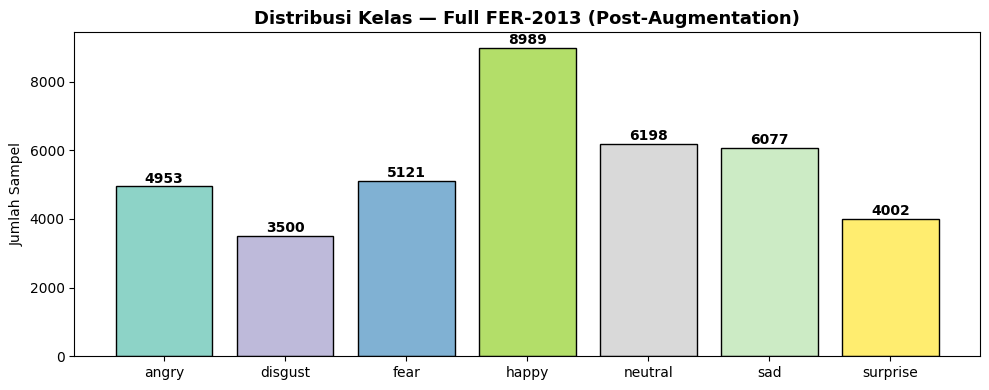


Split stratified (70 / 15 / 15):
  Train : 27203 sampel
  Val   : 5811 sampel
  Test  : 5826 sampel


In [ ]:
# ============================================================
# CELL 5: LOAD DATASET FER-2013
# ============================================================

def augment_image(img):
    """
    Augmentasi yang lebih agresif dan beragam.
    Mencakup: flip, rotasi, brightness/contrast, noise,
    shift, crop, cutout, elastic distortion.
    """
    # Horizontal flip
    if random.random() > 0.5:
        img = cv2.flip(img, 1)
    # Rotasi ±30 derajat
    if random.random() > 0.3:
        angle = random.uniform(-30, 30)
        h, w  = img.shape[:2]
        M     = cv2.getRotationMatrix2D((w // 2, h // 2), angle, 1.0)
        img   = cv2.warpAffine(img, M, (w, h), borderMode=cv2.BORDER_REFLECT)
    # Brightness & Contrast
    if random.random() > 0.3:
        alpha = random.uniform(0.6, 1.4)
        beta  = random.randint(-40, 40)
        img   = np.clip(alpha * img.astype(np.float32) + beta, 0, 255).astype(np.uint8)
    # Gaussian Noise
    if random.random() > 0.4:
        noise = np.random.randn(*img.shape).astype(np.float32) * random.uniform(5, 15)
        img   = np.clip(img.astype(np.float32) + noise, 0, 255).astype(np.uint8)
    # Translation shift
    if random.random() > 0.5:
        sx = random.randint(-8, 8)
        sy = random.randint(-8, 8)
        M_sh = np.float32([[1, 0, sx], [0, 1, sy]])
        img  = cv2.warpAffine(img, M_sh, (img.shape[1], img.shape[0]),
                              borderMode=cv2.BORDER_REFLECT)
    # Random crop & resize
    if random.random() > 0.5:
        h, w = img.shape[:2]
        px   = random.randint(3, 8)
        img  = cv2.resize(img[px:h-px, px:w-px], (w, h),
                          interpolation=cv2.INTER_LINEAR)
    # Gaussian Blur (simulates motion/depth)
    if random.random() > 0.6:
        k = random.choice([3, 5])
        img = cv2.GaussianBlur(img, (k, k), 0)
    # Cutout: random rectangular masking
    if random.random() > 0.6:
        h, w = img.shape[:2]
        ch   = random.randint(8, 16)
        cw   = random.randint(8, 16)
        cy   = random.randint(0, h - ch)
        cx   = random.randint(0, w - cw)
        img[cy:cy+ch, cx:cx+cw] = random.randint(0, 255)
    return img


def apply_clahe(img_uint8):
    """
    CLAHE: Contrast Limited Adaptive Histogram Equalization.
    Meningkatkan kontras lokal — sangat efektif untuk FER2013
    yang banyak memiliki pencahayaan tidak merata.
    """
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(4, 4))
    return clahe.apply(img_uint8)


def load_full_dataset(train_dir, test_dir, cfg):
    """
    Load FULL FER-2013 dengan augmentasi berbasis distribusi kelas.
    Semua kelas minoritas (< TARGET_PER_CLASS) akan diaugmentasi.
    CLAHE diterapkan pada semua gambar.
    """
    X_list, y_list = [], []
    print('\nLoading FULL dataset FER-2013 ...')
    print('-' * 65)

    for label_idx, label in enumerate(cfg.EMOTION_LABELS):
        imgs = []

        # Load dari train + test
        for folder in [train_dir, test_dir]:
            if folder is None:
                continue
            fpath = folder / label
            if not fpath.exists():
                continue
            for p in list(fpath.glob('*.jpg')) + list(fpath.glob('*.png')):
                img = cv2.imread(str(p), cv2.IMREAD_GRAYSCALE)
                if img is None:
                    continue
                img = cv2.resize(img, (cfg.IMG_SIZE, cfg.IMG_SIZE))
                img = apply_clahe(img)  # CLAHE preprocessing
                imgs.append(img)

        original_count = len(imgs)

        # Smart augmentasi: semua kelas di bawah TARGET_PER_CLASS
        target = cfg.TARGET_PER_CLASS
        if original_count < target:
            needed   = target - original_count
            aug_pool = imgs.copy()
            aug_imgs = []
            for i in range(needed):
                aug_img = augment_image(aug_pool[i % len(aug_pool)].copy())
                aug_img = apply_clahe(aug_img)  # CLAHE pada augmented juga
                aug_imgs.append(aug_img)
            imgs += aug_imgs
            print(f'  {label:10s}: {original_count:5d} asli + {needed:5d} aug → {len(imgs):5d}')
        else:
            print(f'  {label:10s}: {original_count:5d} gambar (digunakan semua)')

        X_list.extend(imgs)
        y_list.extend([label_idx] * len(imgs))

    X = np.array(X_list, dtype=np.float32) / 255.0
    y = np.array(y_list, dtype=np.int32)

    print(f'\nTotal dataset: X={X.shape}, y={y.shape}')
    print('Distribusi per kelas setelah augmentasi:')
    for idx, label in enumerate(cfg.EMOTION_LABELS):
        print(f'  {label:10s}: {np.sum(y == idx):5d}')
    return X, y


X_raw, y_raw = load_full_dataset(train_dir, test_dir, cfg)

# Hitung class weights untuk weighted loss
from sklearn.utils.class_weight import compute_class_weight
class_weights_arr = compute_class_weight(
    class_weight='balanced',
    classes=np.arange(cfg.NUM_CLASSES),
    y=y_raw
)
class_weight_dict = {i: float(w) for i, w in enumerate(class_weights_arr)}
print(f'\nClass weights (untuk menangani imbalance residual):')
for idx, label in enumerate(cfg.EMOTION_LABELS):
    print(f'  {label:10s}: {class_weight_dict[idx]:.4f}')

# Visualisasi distribusi kelas
fig, ax = plt.subplots(figsize=(10, 4))
counts  = [np.sum(y_raw == i) for i in range(cfg.NUM_CLASSES)]
colors  = plt.cm.Set3(np.linspace(0, 1, cfg.NUM_CLASSES))
bars    = ax.bar(cfg.EMOTION_LABELS, counts, color=colors, edgecolor='black')
ax.set_title('Distribusi Kelas — Full FER-2013 (Post-Augmentation)', fontsize=13, fontweight='bold')
ax.set_ylabel('Jumlah Sampel')
for bar, count in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width() / 2., bar.get_height() + 20,
            str(count), ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.savefig(f'{cfg.RESULTS_DIR}/dataset_distribution.png', dpi=150)
plt.show()

# Split stratified 70 / 15 / 15
X_temp,  X_test, y_temp, y_test  = train_test_split(
    X_raw, y_raw, test_size=0.15, random_state=42, stratify=y_raw)
X_train, X_val,  y_train, y_val  = train_test_split(
    X_temp, y_temp, test_size=0.176, random_state=42, stratify=y_temp)

print(f'\nSplit stratified (70 / 15 / 15):')
print(f'  Train : {X_train.shape[0]} sampel')
print(f'  Val   : {X_val.shape[0]} sampel')
print(f'  Test  : {X_test.shape[0]} sampel')

# Reshape untuk CNN: (N, H, W, 1)
X_train_cnn = X_train[..., np.newaxis]
X_val_cnn   = X_val[..., np.newaxis]
X_test_cnn  = X_test[..., np.newaxis]

# One-hot encoding
y_train_cat = to_categorical(y_train, cfg.NUM_CLASSES)
y_val_cat   = to_categorical(y_val,   cfg.NUM_CLASSES)
y_test_cat  = to_categorical(y_test,  cfg.NUM_CLASSES)


## Cell 6: Ekstraksi Fitur Matematika Kerutan (LBP + HOG)

In [ ]:
# ============================================================
# CELL 6: EKSTRAKSI FITUR MATEMATIKA KERUTAN WAJAH
# LBP (Local Binary Pattern)            -> Tekstur Kerutan
# HOG (Histogram of Oriented Gradients) -> Bentuk dan Orientasi
# ============================================================

def extract_lbp_features(img_2d, n_points=24, radius=3, n_bins=256):
    """
    LBP: distribusi intensitas piksel tetangga.
    Formula: LBP(p,r) = sum( s(gn - gc) * 2^n ), n=0..P-1
    : kombinasi multi-radius LBP untuk menangkap tekstur multi-skala.
    """
    img_uint8 = (img_2d * 255).astype(np.uint8)
    # Radius 3 — detail halus (pori, kerutan mikro)
    lbp3  = local_binary_pattern(img_uint8, 24, 3, method='uniform')
    hist3, _ = np.histogram(lbp3.ravel(), bins=128, range=(0, 26))
    # Radius 5 — struktur kerutan lebih besar
    lbp5  = local_binary_pattern(img_uint8, 16, 5, method='uniform')
    hist5, _ = np.histogram(lbp5.ravel(), bins=128, range=(0, 18))
    # Gabungkan dan normalisasi
    hist = np.concatenate([hist3, hist5]).astype(np.float32)
    hist /= (hist.sum() + 1e-7)
    # Pad/trim ke LBP_FEATURES
    if len(hist) < n_bins:
        hist = np.pad(hist, (0, n_bins - len(hist)))
    else:
        hist = hist[:n_bins]
    return hist  # shape (n_bins,) = (256,)


def extract_hog_features(img_2d, target_size=324):
    """
    HOG: gradien orientasi -> struktur geometri kerutan.
    : orientations ditingkatkan ke 12 untuk diskriminasi sudut lebih halus.
    """
    img_uint8 = (img_2d * 255).astype(np.uint8)
    feat, _ = hog(
        img_uint8,
        orientations=12,
        pixels_per_cell=(6, 6),
        cells_per_block=(2, 2),
        visualize=True,
        feature_vector=True
    )
    if len(feat) < target_size:
        feat = np.pad(feat, (0, target_size - len(feat)))
    else:
        feat = feat[:target_size]
    feat = feat.astype(np.float32)
    norm = np.linalg.norm(feat) + 1e-7
    return feat / norm  # shape (target_size,)


def extract_all_handcrafted(X_data, cfg, desc=''):
    """Ekstrak LBP + HOG untuk semua gambar secara batch."""
    n       = len(X_data)
    lbp_all = np.zeros((n, cfg.LBP_FEATURES), dtype=np.float32)
    hog_all = np.zeros((n, cfg.HOG_FEATURES), dtype=np.float32)

    for i in tqdm(range(n), desc=f'Ekstrak fitur {desc}', leave=True):
        img2d = X_data[i]
        if img2d.ndim == 3:
            img2d = img2d[..., 0]
        lbp_all[i] = extract_lbp_features(img2d, n_bins=cfg.LBP_FEATURES)
        hog_all[i] = extract_hog_features(img2d, target_size=cfg.HOG_FEATURES)

    return lbp_all, hog_all


print('Mengekstrak fitur LBP dan HOG ...')
lbp_train, hog_train = extract_all_handcrafted(X_train, cfg, 'Train')
lbp_val,   hog_val   = extract_all_handcrafted(X_val,   cfg, 'Val  ')
lbp_test,  hog_test  = extract_all_handcrafted(X_test,  cfg, 'Test ')

print(f'\nLBP train shape : {lbp_train.shape}')
print(f'HOG train shape : {hog_train.shape}')
print('Feature extraction selesai.')


Mengekstrak fitur LBP dan HOG ...


Ekstrak fitur Train:  46%|████▌     | 12502/27203 [03:04<03:27, 70.90it/s]

## Cell 7: ANFIS Custom Keras Layers


In [ ]:
# ============================================================
# CELL 7: ANFIS CUSTOM LAYERS
# Adaptive Neuro-Fuzzy Inference System - 5 Layer Architecture
# ============================================================

class FuzzificationLayer(layers.Layer):
    """
    Layer 1: Fuzzifikasi dengan Gaussian MF.
    mu(x) = exp(-0.5 * ((x - c) / sigma)^2)
    : sigma_init = 0.5 (lebih tajam), centers spread dari -3 ke 3.
    """
    def __init__(self, n_mf=3, sigma_init=0.5, center_range=3.0, **kwargs):
        super().__init__(**kwargs)
        self.n_mf         = n_mf
        self.sigma_init   = sigma_init
        self.center_range = center_range

    def build(self, input_shape):
        input_dim    = int(input_shape[-1])
        init_c       = np.linspace(-self.center_range, self.center_range,
                                    self.n_mf).astype(np.float32)
        centers_init = np.tile(init_c, (input_dim, 1))
        self.centers = self.add_weight(
            name='centers',
            shape=(input_dim, self.n_mf),
            initializer=tf.constant_initializer(centers_init),
            trainable=True
        )
        self.sigmas = self.add_weight(
            name='sigmas',
            shape=(input_dim, self.n_mf),
            initializer=tf.constant_initializer(self.sigma_init),
            constraint=tf.keras.constraints.NonNeg(),
            trainable=True
        )
        super().build(input_shape)

    def call(self, x):
        x_exp = tf.expand_dims(x, axis=-1)                 # (B, D, 1)
        c     = self.centers                               # (D, n_mf)
        s     = tf.abs(self.sigmas) + 1e-7                 # (D, n_mf)
        mu    = tf.exp(-0.5 * tf.square((x_exp - c) / s))  # (B, D, n_mf)
        return mu

    def get_config(self):
        cfg_out = super().get_config()
        cfg_out.update({
            'n_mf': self.n_mf,
            'sigma_init': self.sigma_init,
            'center_range': self.center_range
        })
        return cfg_out


class GeneralizedBellMFLayer(layers.Layer):
    """
    Generalized Bell Membership Function sebagai alternatif Gaussian.
    bell(x) = 1 / (1 + |((x - c) / a)|^(2b))
    Lebih lebar di ujung, lebih "lunak" dalam transisi membership.
    """
    def __init__(self, n_mf=5, **kwargs):
        super().__init__(**kwargs)
        self.n_mf = n_mf

    def build(self, input_shape):
        input_dim = int(input_shape[-1])
        init_c    = np.linspace(-2, 2, self.n_mf).astype(np.float32)
        self.centers = self.add_weight(
            name='centers',
            shape=(input_dim, self.n_mf),
            initializer=tf.constant_initializer(np.tile(init_c, (input_dim, 1))),
            trainable=True
        )
        self.a = self.add_weight(
            name='a',
            shape=(input_dim, self.n_mf),
            initializer=tf.constant_initializer(1.0),
            constraint=tf.keras.constraints.NonNeg(),
            trainable=True
        )
        self.b = self.add_weight(
            name='b',
            shape=(input_dim, self.n_mf),
            initializer=tf.constant_initializer(2.0),
            constraint=tf.keras.constraints.NonNeg(),
            trainable=True
        )
        super().build(input_shape)

    def call(self, x):
        x_exp = tf.expand_dims(x, axis=-1)              # (B, D, 1)
        a     = tf.abs(self.a) + 1e-7
        b     = tf.abs(self.b) + 0.5
        ratio = tf.abs((x_exp - self.centers) / a)
        mu    = 1.0 / (1.0 + tf.pow(ratio, 2.0 * b))
        return mu                                       # (B, D, n_mf)

    def get_config(self):
        cfg_out = super().get_config()
        cfg_out['n_mf'] = self.n_mf
        return cfg_out


class FuzzyRuleLayer(layers.Layer):
    """
    Layer 2: Rule Firing Strength via T-norm (product).
    w_k = product( mu_ij(x_i) ) untuk rule ke-k
    : dropout pada rule_weights untuk regularisasi.
    """
    def __init__(self, n_rules=16, n_mf=3, **kwargs):
        super().__init__(**kwargs)
        self.n_rules = n_rules
        self.n_mf    = n_mf

    def build(self, input_shape):
        input_dim = int(input_shape[1])  # D
        self.rule_weights = self.add_weight(
            name='rule_weights',
            shape=(self.n_rules, input_dim, self.n_mf),
            initializer='glorot_uniform',
            trainable=True
        )
        super().build(input_shape)

    def call(self, mu, training=None):
        rw_soft  = tf.nn.softmax(self.rule_weights, axis=-1)  # (n_rules, D, n_mf)
        if training:
            rw_soft = tf.nn.dropout(rw_soft, rate=0.05)
        mu_exp   = tf.expand_dims(mu, axis=1)                 # (B, 1, D, n_mf)
        selected = tf.reduce_sum(mu_exp * rw_soft, axis=-1)   # (B, n_rules, D)
        w        = tf.reduce_prod(selected + 1e-7, axis=-1)   # (B, n_rules)
        return w

    def get_config(self):
        cfg_out = super().get_config()
        cfg_out.update({'n_rules': self.n_rules, 'n_mf': self.n_mf})
        return cfg_out


class NormalizationLayer(layers.Layer):
    """
    Layer 3: Normalisasi Rule Firing Strength.
    w_bar_k = w_k / sum(w_j)
    """
    def call(self, w):
        w_sum = tf.reduce_sum(w, axis=-1, keepdims=True) + 1e-7
        return w / w_sum  # (B, n_rules)


class ConsequentLayer(layers.Layer):
    """
    Layer 4: Defuzzifikasi TSK (Takagi-Sugeno-Kang).
    f_k(x) = p_k0 + sum( p_ki * x_i )
    y = sum( w_bar_k * f_k(x) )
    : Tambah LayerNormalization untuk stabilitas gradien.
    """
    def __init__(self, n_rules, input_dim, output_dim, **kwargs):
        super().__init__(**kwargs)
        self.n_rules    = n_rules
        self.input_dim  = input_dim
        self.output_dim = output_dim

    def build(self, input_shape):
        self.p = self.add_weight(
            name='consequent_p',
            shape=(self.n_rules, self.input_dim + 1, self.output_dim),
            initializer='glorot_uniform',
            regularizer=tf.keras.regularizers.l2(1e-5),
            trainable=True
        )
        super().build(input_shape)

    def call(self, inputs):
        w_bar, x = inputs
        bias  = tf.ones_like(x[:, :1])
        x_aug = tf.concat([x, bias], axis=1)             # (B, D+1)
        fk    = tf.einsum('bd,kdo->bko', x_aug, self.p)  # (B, n_rules, output_dim)
        w_exp = tf.expand_dims(w_bar, axis=-1)           # (B, n_rules, 1)
        out   = tf.reduce_sum(w_exp * fk, axis=1)        # (B, output_dim)
        return out

    def get_config(self):
        cfg_out = super().get_config()
        cfg_out.update({
            'n_rules':    self.n_rules,
            'input_dim':  self.input_dim,
            'output_dim': self.output_dim
        })
        return cfg_out


print('ANFIS custom layers :')
print('  1. FuzzificationLayer          -- Gaussian MF (sigma=0.5, range=[-3,3])')
print('  2. GeneralizedBellMFLayer      -- Bell MF (alternatif, lebih soft transition)')
print('  3. FuzzyRuleLayer              -- T-norm Product + rule dropout')
print('  4. NormalizationLayer          -- w_bar normalisasi')
print('  5. ConsequentLayer             -- TSK + L2 regularization')


## Cell 8: Membangun Model A (Baseline) & Model B (ANFIS Hybrid)

In [ ]:
# ============================================================
# CELL 8A: MODEL A — BASELINE MLP CLASSIFIER
# ============================================================

def build_mlp_baseline_model(cfg):
    """
    Model A: CNN+LBP+HOG Feature Fusion + Dense MLP Classifier.

    Tidak ada fuzzifikasi, rule firing, atau defuzzifikasi.
    Decision boundary bersifat hard/crisp (hyperplane linear).
    """
    img_input = layers.Input(
        shape=(cfg.IMG_SIZE, cfg.IMG_SIZE, cfg.CHANNELS), name='input_image')
    lbp_input = layers.Input(shape=(cfg.LBP_FEATURES,), name='input_lbp')
    hog_input = layers.Input(shape=(cfg.HOG_FEATURES,), name='input_hog')

    # --- CNN Branch ---
    x = layers.Resizing(96, 96)(img_input)
    x = layers.Concatenate()([x, x, x])
    base_model = MobileNetV2(
        input_shape=(96, 96, 3), include_top=False,
        weights='imagenet', pooling='avg')
    base_model.trainable = False
    x = base_model(x, training=False)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(cfg.CNN_FEATURES, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)
    cnn_feat = x  # (B, 256)

    # --- LBP Branch ---
    lbp_feat = layers.BatchNormalization(name='lbp_bn')(lbp_input)

    # --- HOG Branch ---
    hog_feat = layers.BatchNormalization(name='hog_bn')(hog_input)

    # --- Feature Fusion ---
    fused = layers.Concatenate(name='feature_fusion')([cnn_feat, lbp_feat, hog_feat])

    # Cross-branch attention
    attn  = layers.Dense(cfg.FUSED_DIM, activation='sigmoid', name='cross_attention')(fused)
    fused = layers.Multiply(name='attended_features')([fused, attn])

    # --- MLP DECISION LAYERS ---
    z = layers.Dense(256, activation='relu', name='mlp_dense1')(fused)
    z = layers.BatchNormalization(name='mlp_bn1')(z)
    z = layers.Dropout(0.4)(z)

    z = layers.Dense(128, activation='relu', name='mlp_dense2')(z)
    z = layers.BatchNormalization(name='mlp_bn2')(z)
    z = layers.Dropout(0.4)(z)

    z = layers.Dense(64, activation='relu', name='mlp_dense3')(z)
    z = layers.BatchNormalization(name='mlp_bn3')(z)
    z = layers.Dropout(0.3)(z)

    # Skip connection dari fused → mlp output
    fused_proj = layers.Dense(64, use_bias=False, name='skip_projection')(fused)
    combined   = layers.Add(name='residual_connection')([z, fused_proj])
    combined   = layers.BatchNormalization(name='combined_bn')(combined)
    combined   = layers.Activation('relu', name='combined_relu')(combined)

    # Output Head — Klasifikasi Emosi (7 kelas)
    emo         = layers.Dense(32, activation='relu', name='emotion_dense1')(combined)
    emo         = layers.Dropout(0.3)(emo)
    emotion_out = layers.Dense(
        cfg.NUM_CLASSES, activation='softmax', name='emotion_output')(emo)

    model_a = tf.keras.Model(
        inputs=[img_input, lbp_input, hog_input],
        outputs=emotion_out,
        name='Model_A_MLP_Baseline')

    model_a.compile(
        optimizer=Adam(learning_rate=cfg.LEARNING_RATE, clipnorm=1.0),
        loss='categorical_crossentropy',
        metrics=['accuracy'])

    return model_a


model_a = build_mlp_baseline_model(cfg)
model_a.summary(line_length=90)

total_a     = model_a.count_params()
trainable_a = sum([K.count_params(w) for w in model_a.trainable_weights])
print(f'\n[Model A — Baseline MLP]')
print(f'  Total parameter    : {total_a:,}')
print(f'  Trainable parameter: {trainable_a:,}')

In [ ]:
# ============================================================
# CELL 8B: MODEL A — ANFIS HYBRID
# ============================================================

def build_cnn_branch(input_tensor, cfg):
    """CNN Branch: MobileNetV2 pre-trained."""
    x = layers.Resizing(96, 96)(input_tensor)
    x = layers.Concatenate()([x, x, x])
    base_model = MobileNetV2(
        input_shape=(96, 96, 3),
        include_top=False,
        weights='imagenet',
        pooling='avg'
    )

    base_model.trainable = True
    for layer in base_model.layers[:-cfg.CNN_FINETUNE_LAYERS]:
        layer.trainable = False

    for layer in base_model.layers[:-cfg.CNN_FINETUNE_LAYERS]:
        if isinstance(layer, layers.BatchNormalization):
            layer.trainable = False

    x = base_model(x, training=True)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(cfg.CNN_FEATURES, activation='relu',
                     kernel_regularizer=tf.keras.regularizers.l2(1e-5))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)
    return x  # (B, 256)


def build_lbp_branch(input_tensor, cfg):
    """LBP branch: Dense projection untuk trainable feature transform."""
    x = layers.BatchNormalization(name='lbp_bn')(input_tensor)
    x = layers.Dense(128, activation='tanh', name='lbp_project',
                     kernel_regularizer=tf.keras.regularizers.l2(1e-5))(x)
    x = layers.BatchNormalization(name='lbp_project_bn')(x)
    x = layers.Dropout(0.2, name='lbp_dropout')(x)
    return x  # (B, 128)


def build_hog_branch_anfis(input_tensor, cfg):
    """HOG branch — kompresi ke 128 dengan tanh."""
    x = layers.BatchNormalization(name='hog_bn')(input_tensor)
    x = layers.Dense(128, activation='tanh', name='hog_compress',
                     kernel_regularizer=tf.keras.regularizers.l2(1e-5))(x)
    x = layers.BatchNormalization(name='hog_compress_bn')(x)
    x = layers.Dropout(0.2, name='hog_dropout')(x)
    return x  # (B, 128)


def build_anfis_hybrid_model(cfg):
    """
    ANFIS Hybrid Model .
    Architecture highlights:
    - CNN 256 + LBP 128 + HOG 128 = 512-dim fused
    - Dual fuzzification: Gaussian (standard) + BellMF (HOG dims)
    - ANFIS: 64-dim COMPRESS, 48 rules, 5 MF
    - Label smoothing loss
    """

    # -- INPUT LAYERS --
    img_input = layers.Input(
        shape=(cfg.IMG_SIZE, cfg.IMG_SIZE, cfg.CHANNELS), name='input_image')
    lbp_input = layers.Input(shape=(cfg.LBP_FEATURES,), name='input_lbp')
    hog_input = layers.Input(shape=(cfg.HOG_FEATURES,), name='input_hog')

    # -- BRANCHES --
    cnn_feat = build_cnn_branch(img_input, cfg)   # (B, 256)
    lbp_feat = build_lbp_branch(lbp_input, cfg)   # (B, 128)  ← : trainable
    hog_feat = build_hog_branch_anfis(hog_input, cfg)  # (B, 128)

    # -- FEATURE FUSION --
    fused = layers.Concatenate(name='feature_fusion')([cnn_feat, lbp_feat, hog_feat])
    fused_dim_actual = 256 + 128 + 128  # = 512
    attn  = layers.Dense(fused_dim_actual, activation='sigmoid',
                         name='cross_attention')(fused)
    fused = layers.Multiply(name='attended_features')([fused, attn])

    # -- FUZZY FEATURE COMPRESSION --
    z = layers.Dense(256, activation='relu', name='fusion_proj_1',
                     kernel_regularizer=tf.keras.regularizers.l2(1e-5))(fused)
    z = layers.BatchNormalization(name='fusion_bn_1')(z)
    z = layers.Dropout(0.4)(z)
    z = layers.Dense(cfg.COMPRESS_DIM, activation='tanh', name='anfis_projection',
                     kernel_regularizer=tf.keras.regularizers.l2(1e-5))(z)
    z = layers.LayerNormalization(name='anfis_layernorm')(z)

    # -- DUAL FUZZIFICATION --
    hog_dim  = max(1, cfg.COMPRESS_DIM // 3)    # = 21
    rest_dim = cfg.COMPRESS_DIM - hog_dim       # = 43
    z_hog  = layers.Lambda(lambda t: t[:, :hog_dim],  name='split_hog_dims')(z)
    z_rest = layers.Lambda(lambda t: t[:, hog_dim:], name='split_rest_dims')(z)

    mu_hog  = GeneralizedBellMFLayer(
        n_mf=cfg.FUZZY_MF, name='l1_fuzz_hog_bell')(z_hog)

    mu_rest = FuzzificationLayer(
        n_mf=cfg.FUZZY_MF, sigma_init=0.5, center_range=2.5,
        name='l1_fuzz_standard')(z_rest)

    # Flatten & unify ke unified representation
    mu_hog_flat   = layers.Reshape((hog_dim * cfg.FUZZY_MF,),  name='reshape_mu_hog')(mu_hog)
    mu_rest_flat  = layers.Reshape((rest_dim * cfg.FUZZY_MF,), name='reshape_mu_rest')(mu_rest)
    mu_combined   = layers.Concatenate(name='mu_concat')([mu_hog_flat, mu_rest_flat])

    # Project ke (COMPRESS_DIM, FUZZY_MF) tensor untuk Rule Layer
    unified_mf_dim = cfg.COMPRESS_DIM * cfg.FUZZY_MF
    mu_unified  = layers.Dense(unified_mf_dim, activation='sigmoid',
                                name='mu_unification')(mu_combined)
    mu_reshaped = layers.Reshape((cfg.COMPRESS_DIM, cfg.FUZZY_MF),
                                  name='mu_reshape')(mu_unified)


    # -- ANFIS CORE (5 LAYERS) --
    w = FuzzyRuleLayer(
        n_rules=cfg.ANFIS_RULES,
        n_mf=cfg.FUZZY_MF,
        name='l2_fuzzy_rules'
    )(mu_reshaped)

    w_bar = NormalizationLayer(name='l3_normalization')(w)

    anfis_out = ConsequentLayer(
        n_rules=cfg.ANFIS_RULES,
        input_dim=cfg.COMPRESS_DIM,
        output_dim=cfg.ANFIS_DIM,    # 128
        name='l4_consequent'
    )([w_bar, z])

    anfis_out = layers.LayerNormalization(name='l5_defuzz_layernorm')(anfis_out)
    anfis_out = layers.Activation('gelu', name='l5_defuzzification')(anfis_out)
    anfis_out = layers.Dropout(0.3)(anfis_out)

    # SKIP CONNECTION dengan fused bias (CNN-LBP-HOG)
    fused_proj = layers.Dense(cfg.ANFIS_DIM, use_bias=False,
                               name='skip_projection')(fused)
    combined   = layers.Add(name='residual_connection')([anfis_out, fused_proj])
    combined   = layers.LayerNormalization(name='combined_layernorm')(combined)
    combined   = layers.Activation('gelu', name='combined_gelu')(combined)

    # EMOTION OUTPUT HEAD
    emo = layers.Dense(64, activation='relu', name='emotion_dense1',
                       kernel_regularizer=tf.keras.regularizers.l2(1e-5))(combined)
    emo = layers.Dropout(0.3)(emo)
    emo = layers.Dense(32, activation='relu', name='emotion_dense2')(emo)
    emotion_out = layers.Dense(
        cfg.NUM_CLASSES, activation='softmax', name='emotion_output')(emo)

    # STRESS OUTPUT HEAD
    stress = layers.Dense(64, activation='relu', name='stress_dense1')(combined)
    stress = layers.Dropout(0.3)(stress)
    stress = layers.Dense(32, activation='relu', name='stress_dense2')(stress)
    stress_out = layers.Dense(1, activation='sigmoid', name='stress_output')(stress)

    # COMPILE dengan label smoothing + cosine decay LR
    total_steps = (35000 // cfg.BATCH_SIZE) * cfg.EPOCHS
    lr_schedule = tf.keras.optimizers.schedules.CosineDecayRestarts(
        initial_learning_rate=cfg.LEARNING_RATE,
        first_decay_steps=total_steps // 4,
        t_mul=1.5,
        m_mul=0.9,
        alpha=1e-6
    )
    optimizer = tf.keras.optimizers.AdamW(
        learning_rate=lr_schedule,
        weight_decay=1e-5,
        clipnorm=2.0
    )

    model = tf.keras.Model(
        inputs=[img_input, lbp_input, hog_input],
        outputs=[emotion_out, stress_out],
        name='ANFIS_Hybrid_FacialEmotion'
    )

    model.compile(
        optimizer=optimizer,
        loss={
            'emotion_output': tf.keras.losses.CategoricalCrossentropy(
                label_smoothing=0.05
            ),
            'stress_output': 'mse'
        },
        loss_weights={
            'emotion_output': cfg.EMOTION_LOSS_WEIGHT,
            'stress_output':  cfg.STRESS_LOSS_WEIGHT,
        },
        metrics={
            'emotion_output': ['accuracy'],
            'stress_output':  ['mae']
        }
    )
    return model


# Build model
model_b = build_anfis_hybrid_model(cfg)
model_b.summary(line_length=95)

total_params    = model_b.count_params()
trainable_params = sum([K.count_params(w) for w in model_b.trainable_weights])
print(f'\n[ANFIS Hybrid ]')
print(f'  Total parameter    : {total_params:,}')
print(f'  Trainable parameter: {trainable_params:,}')
print(f'  CNN fine-tuning    : top {cfg.CNN_FINETUNE_LAYERS} layers of MobileNetV2')
print(f'  LBP branch         : Dense(128, tanh) — sebelumnya hanya BN')
print(f'  ANFIS rules        : {cfg.ANFIS_RULES} (was: 32)')
print(f'  ANFIS dim          : {cfg.ANFIS_DIM} (was: 64)')
print(f'  Compress dim       : {cfg.COMPRESS_DIM} (was: 32)')
print(f'  Fuzzy MF           : {cfg.FUZZY_MF} (was: 3)')
print(f'  Loss weights       : emotion={cfg.EMOTION_LOSS_WEIGHT}, stress={cfg.STRESS_LOSS_WEIGHT}')
print(f'  Label smoothing    : 0.05')
print(f'  Optimizer          : AdamW + CosineDecayRestarts')


## Cell 9: Stress Label Generator

In [ ]:
# ============================================================
# CELL 9: STRESS LEVEL LABEL GENERATOR
# Mengkonversi label emosi ke nilai stress kontinu (0-1)
# ============================================================

def generate_stress_labels(y_int, cfg, noise_std=0.05):
    """
    Stress level dihitung berdasarkan:
    - Bobot emosi (stress_weights)
    - Gaussian noise kecil untuk variasi natural
    - Nilai dijaga dalam [0, 1]
    """
    stress_vals = np.zeros(len(y_int), dtype=np.float32)
    for i, label_idx in enumerate(y_int):
        label_name     = cfg.EMOTION_LABELS[label_idx]
        base_stress    = cfg.STRESS_WEIGHTS[label_name]
        noise          = np.random.normal(0, noise_std)
        stress_vals[i] = float(np.clip(base_stress + noise, 0.0, 1.0))
    return stress_vals


stress_train = generate_stress_labels(y_train, cfg)
stress_val   = generate_stress_labels(y_val,   cfg)
stress_test  = generate_stress_labels(y_test,  cfg)

print('Stress labels dibuat:')
print(f'  Train: mean={stress_train.mean():.3f}, std={stress_train.std():.3f}')
print(f'  Val  : mean={stress_val.mean():.3f}, std={stress_val.std():.3f}')
print(f'  Test : mean={stress_test.mean():.3f}, std={stress_test.std():.3f}')

# Visualisasi distribusi stress
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(stress_train, bins=30, color='steelblue', alpha=0.7, edgecolor='white')
axes[0].axvline(stress_train.mean(), color='red', linestyle='--',
                label=f'Mean={stress_train.mean():.2f}')
axes[0].set_title('Distribusi Stress Level (Train)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Stress Level (0=Low, 1=High)')
axes[0].set_ylabel('Frekuensi')
axes[0].legend()

emotion_stress_data = {}
for i, label in enumerate(cfg.EMOTION_LABELS):
    mask = y_train == i
    emotion_stress_data[label] = stress_train[mask]

stress_box = [emotion_stress_data[l] for l in cfg.EMOTION_LABELS]
axes[1].boxplot(stress_box, labels=cfg.EMOTION_LABELS, patch_artist=True,
                boxprops=dict(facecolor='lightblue', color='navy'),
                medianprops=dict(color='red', linewidth=2))
axes[1].set_title('Stress Level per Emosi', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Emosi')
axes[1].set_ylabel('Stress Level')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig(f'{cfg.RESULTS_DIR}/stress_distribution.png', dpi=150)
plt.show()
print('Plot stress distribution tersimpan')

## Cell 10: Training Model A (Baseline) & Model B (ANFIS Hybrid)

In [ ]:
# ============================================================
# CELL 10A: TRAINING MODEL A — BASELINE MLP
# Dataset: single output (emotion only)
# ============================================================

def make_dataset_single_output(X_cnn, X_lbp, X_hog, y_cat,
                                batch_size, shuffle=True):
    """Dataset tf.data untuk Model A (satu output: emotion)."""
    ds = tf.data.Dataset.from_tensor_slices((
        {'input_image': X_cnn, 'input_lbp': X_lbp, 'input_hog': X_hog},
        y_cat
    ))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(X_cnn), reshuffle_each_iteration=True)
    return ds.batch(cfg.BATCH_SIZE).prefetch(tf.data.AUTOTUNE)


train_ds_a = make_dataset_single_output(
    X_train_cnn, lbp_train, hog_train, y_train_cat, cfg.BATCH_SIZE)
val_ds_a   = make_dataset_single_output(
    X_val_cnn, lbp_val, hog_val, y_val_cat, cfg.BATCH_SIZE, shuffle=False)

callbacks_a = [
    EarlyStopping(monitor='val_accuracy', patience=10,
                  restore_best_weights=True, verbose=1, mode='max'),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5,
                      min_lr=1e-6, verbose=1),
    ModelCheckpoint(filepath=cfg.MODEL_A_PATH,
                    monitor='val_accuracy', save_best_only=True,
                    save_weights_only=True, verbose=1, mode='max'),
]

# --- Training ---
print('Training Model A (Baseline MLP)...')
print(f'  Epochs  : {cfg.EPOCHS}')
print(f'  Batch   : {cfg.BATCH_SIZE}')
print(f'  Samples : {X_train_cnn.shape[0]}')
print()

history_a = model_a.fit(
    train_ds_a,
    validation_data=val_ds_a,
    epochs=cfg.EPOCHS,
    callbacks=callbacks_a,
    class_weight=class_weight_dict,
    verbose=1,
)

best_val_a = max(history_a.history.get('val_accuracy', [0]))
print(f'\n[Model A] Best Val Accuracy: {best_val_a:.4f} ({best_val_a*100:.2f}%)')

In [ ]:
# ============================================================
# CELL 10B: TRAINING MODEL B — ANFIS HYBRID
# Dataset: dual output (emotion + stress)
# ============================================================

def make_dataset_dual_output(X_cnn, X_lbp, X_hog, y_cat, y_stress,
                              sample_weights, batch_size, shuffle=True):
    """
    Dataset tf.data untuk Model B (dua output: emotion + stress).
    """
    ds = tf.data.Dataset.from_tensor_slices((
        {'input_image': X_cnn, 'input_lbp': X_lbp, 'input_hog': X_hog},
        {'emotion_output': y_cat, 'stress_output': y_stress},
        sample_weights
    ))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(X_cnn), reshuffle_each_iteration=True)
    return ds.batch(batch_size, drop_remainder=False).prefetch(tf.data.AUTOTUNE)


def compute_sample_weights(y_int, class_weight_dict):
    """
    Konversi class_weight_dict ke per-sample weight array.
    """
    return np.array([class_weight_dict[label_idx] for label_idx in y_int],
                    dtype=np.float32)


# Hitung per-sample weights dari distribusi kelas
sample_weights_train = compute_sample_weights(y_train, class_weight_dict)
sample_weights_val   = compute_sample_weights(y_val,   class_weight_dict)

print('Sample weight stats (train):')
print(f'  min={sample_weights_train.min():.4f}, max={sample_weights_train.max():.4f}, '
      f'mean={sample_weights_train.mean():.4f}')

# Build tf.data datasets dengan sample_weight
train_ds_b = make_dataset_dual_output(
    X_train_cnn, lbp_train, hog_train,
    y_train_cat, stress_train,
    sample_weights_train, cfg.BATCH_SIZE, shuffle=True)

val_ds_b = make_dataset_dual_output(
    X_val_cnn, lbp_val, hog_val,
    y_val_cat, stress_val,
    sample_weights_val, cfg.BATCH_SIZE, shuffle=False)


class LearningRateLogger(tf.keras.callbacks.Callback):
    """Log learning rate aktif setiap akhir epoch."""
    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        try:
            lr_sched = self.model.optimizer.learning_rate
            if isinstance(lr_sched, tf.keras.optimizers.schedules.LearningRateSchedule):
                lr_val = float(lr_sched(self.model.optimizer.iterations).numpy())
            else:
                lr_val = float(tf.keras.backend.get_value(lr_sched))
        except Exception:
            lr_val = float(self.model.optimizer.learning_rate)
        logs['lr'] = lr_val


class SWACallback(tf.keras.callbacks.Callback):
    """
    Stochastic Weight Averaging.
    """
    def __init__(self, swa_start_epoch=50, **kwargs):
        super().__init__(**kwargs)
        self.swa_start_epoch = swa_start_epoch
        self.swa_weights     = None
        self.swa_count       = 0

    def on_epoch_end(self, epoch, logs=None):
        if epoch >= self.swa_start_epoch:
            current = self.model.get_weights()
            if self.swa_weights is None:
                self.swa_weights = [w.copy() for w in current]
                self.swa_count   = 1
            else:
                self.swa_count += 1
                n = self.swa_count
                self.swa_weights = [
                    swa_w * (n - 1) / n + cur_w / n
                    for swa_w, cur_w in zip(self.swa_weights, current)
                ]

    def on_train_end(self, logs=None):
        if self.swa_weights is not None and self.swa_count > 0:
            self.model.set_weights(self.swa_weights)
            print(f'\n[SWA] Running average dari {self.swa_count} epoch diterapkan.')
        else:
            print('\n[SWA] Tidak aktif (SWA start epoch belum tercapai).')


swa_start = max(10, cfg.EPOCHS - 20)
swa_cb    = SWACallback(swa_start_epoch=swa_start)

callbacks_b = [
    LearningRateLogger(),
    EarlyStopping(
        monitor='val_emotion_output_accuracy',
        patience=12,
        restore_best_weights=False,
        verbose=1,
        mode='max'
    ),
    ModelCheckpoint(
        filepath=cfg.MODEL_B_PATH,
        monitor='val_emotion_output_accuracy',
        save_best_only=True,
        save_weights_only=True,
        verbose=1,
        mode='max'
    ),
    swa_cb,
]

print('=' * 60)
print('Training Model B — ANFIS Hybrid')
print('=' * 60)
print(f'  Epochs          : {cfg.EPOCHS}')
print(f'  Batch size      : {cfg.BATCH_SIZE}')
print(f'  Train samples   : {X_train_cnn.shape[0]}')
print(f'  SWA start epoch : {swa_start}')
print()

history_b = model_b.fit(
    train_ds_b,
    validation_data=val_ds_b,
    epochs=cfg.EPOCHS,
    callbacks=callbacks_b,
    verbose=1,
)

if os.path.exists(cfg.MODEL_B_PATH):
    # Simpan bobot SWA dulu ke temporary
    swa_weights_final = model_b.get_weights()

    # Load best checkpoint
    model_b.load_weights(cfg.MODEL_B_PATH)
    print('[Checkpoint] Best checkpoint weights dimuat.')
else:
    swa_weights_final = model_b.get_weights()
    print('[Warning] Checkpoint tidak ditemukan, menggunakan SWA weights.')

best_val_b = max(history_b.history.get('val_emotion_output_accuracy', [0]))
print(f'\n[Model B] Best Val Accuracy (history): {best_val_b:.4f} ({best_val_b*100:.2f}%)')


Sample weight stats (train):
  min=0.6173, max=1.5853, mean=1.0000
Training Model B — ANFIS Hybrid
  Epochs          : 80
  Batch size      : 64
  Train samples   : 27203
  SWA start epoch : 60

Epoch 1/80
426/426 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - emotion_output_accuracy: 0.2984 - emotion_output_loss: 1.7629 - loss: 1.7840 - stress_output_loss: 0.0997 - stress_output_mae: 0.2952
Epoch 1: val_emotion_output_accuracy improved from None to 0.45792, saving model to /content/anfis_emotion_model.weights.h5

Epoch 1: finished saving model to /content/anfis_emotion_model.weights.h5
426/426 ━━━━━━━━━━━━━━━━━━━━ 99s 113ms/step - emotion_output_accuracy: 0.3923 - emotion_output_loss: 1.5917 - loss: 1.6106 - stress_output_loss: 0.0868 - stress_output_mae: 0.2712 - val_emotion_output_accuracy: 0.4579 - val_emotion_output_loss: 1.5068 - val_loss: 1.5219 - val_stress_output_loss: 0.0721 - val_stress_output_mae: 0.2239 - lr: 2.9887e-04
Epoch 2/80
424/426 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - emotion_o

## Cell 11: Visualisasi Kurva Training — Model A & Model B

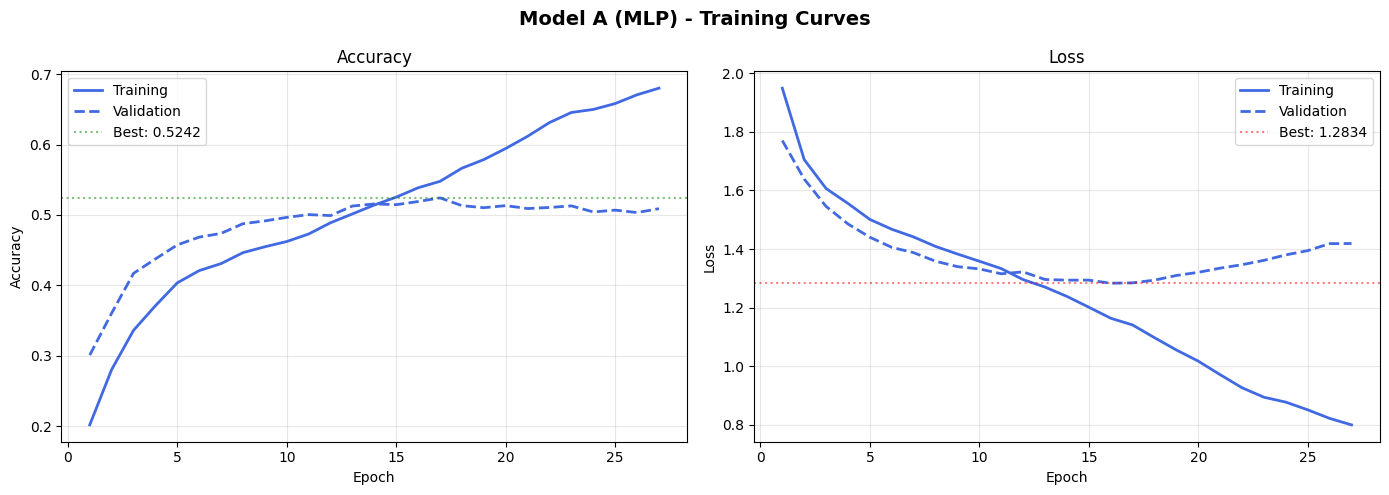

Kurva Model A (MLP) tersimpan.


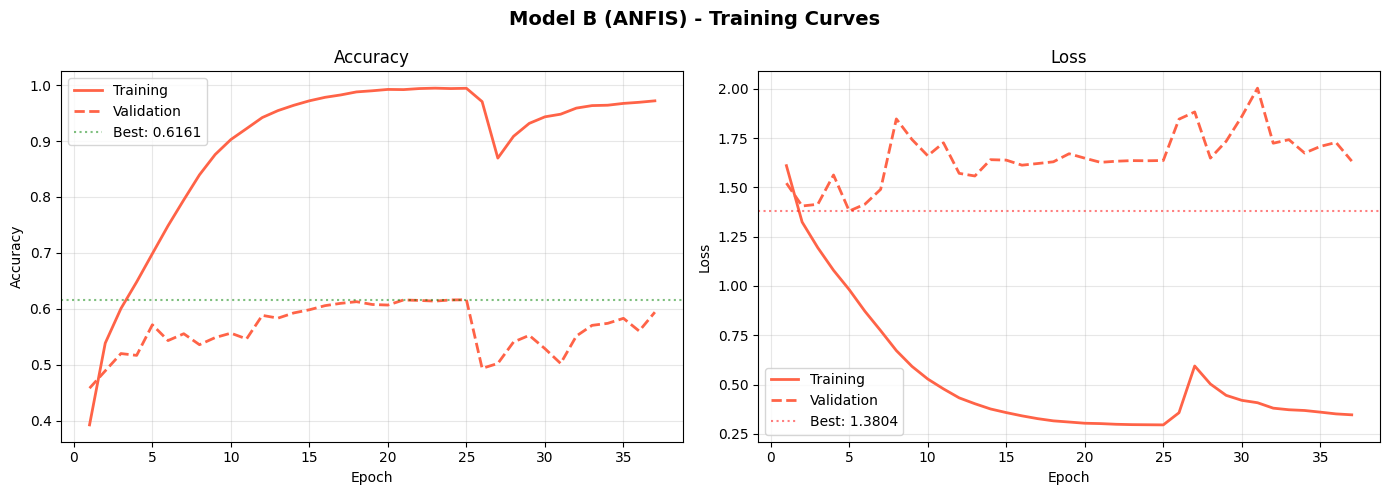

Kurva Model B (ANFIS) tersimpan.


In [ ]:
# ============================================================
# CELL 11: VISUALISASI KURVA TRAINING
# ============================================================

# Model A saja
def plot_single_model(history, model_name, color, save_dir):
    hist = history.history
    epochs = range(1, len(hist.get('loss', [])) + 1)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'{model_name} - Training Curves', fontsize=14, fontweight='bold')

    # Accuracy
    train_acc = hist.get('accuracy', hist.get('emotion_output_accuracy', []))
    val_acc = hist.get('val_accuracy', hist.get('val_emotion_output_accuracy', []))

    ax1.plot(epochs, train_acc, color=color, lw=2, label='Training')
    ax1.plot(epochs, val_acc, color=color, lw=2, ls='--', label='Validation')
    if val_acc:
        best = max(val_acc)
        ax1.axhline(best, color='green', ls=':', alpha=0.5, label=f'Best: {best:.4f}')
    ax1.set_title('Accuracy')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Accuracy')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # Loss
    train_loss = hist.get('loss', [])
    val_loss = hist.get('val_loss', [])

    ax2.plot(epochs, train_loss, color=color, lw=2, label='Training')
    ax2.plot(epochs, val_loss, color=color, lw=2, ls='--', label='Validation')
    if val_loss:
        best_loss = min(val_loss)
        ax2.axhline(best_loss, color='red', ls=':', alpha=0.5, label=f'Best: {best_loss:.4f}')
    ax2.set_title('Loss')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'{save_dir}/{model_name.lower().replace(" ", "_")}_curves.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Kurva {model_name} tersimpan.')


# Eksekusi masing-masing
plot_single_model(history_a, 'Model A (MLP)', 'royalblue', cfg.RESULTS_DIR)
plot_single_model(history_b, 'Model B (ANFIS)', 'tomato', cfg.RESULTS_DIR)

## Cell 12: Evaluasi Model A & Model B pada Test Set

In [ ]:
# ============================================================
# CELL 12: EVALUASI DAN PERBANDINGAN MODEL A vs MODEL B
# ============================================================

# Load best weights
if os.path.exists(cfg.MODEL_A_PATH):
    model_a.load_weights(cfg.MODEL_A_PATH)
    print('[Model A] Best weights loaded.')
if os.path.exists(cfg.MODEL_B_PATH):
    model_b.load_weights(cfg.MODEL_B_PATH)
    print('[Model B] Best weights loaded.')

# ---- Prediksi Model A ----
test_ds_a = make_dataset_single_output(
    X_test_cnn, lbp_test, hog_test, y_test_cat, cfg.BATCH_SIZE, shuffle=False)

pred_a_list = []
for batch_inputs, _ in test_ds_a:
    out = model_a(
        [batch_inputs['input_image'],
         batch_inputs['input_lbp'],
         batch_inputs['input_hog']], training=False)
    pred_a_list.append(out.numpy())
probs_a  = np.concatenate(pred_a_list, axis=0)
y_pred_a = np.argmax(probs_a, axis=1)

# ---- Prediksi Model B ----
sample_weights_test = np.ones(len(X_test_cnn), dtype=np.float32)
test_ds_b = make_dataset_dual_output(
    X_test_cnn, lbp_test, hog_test, y_test_cat, stress_test,
    sample_weights_test,
    cfg.BATCH_SIZE,
    shuffle=False)

pred_b_list, stress_b_list = [], []
for batch_inputs, _, _ in test_ds_b:
    ep_b, sp_b = model_b(
        [batch_inputs['input_image'],
         batch_inputs['input_lbp'],
         batch_inputs['input_hog']], training=False)
    pred_b_list.append(ep_b.numpy())
    stress_b_list.append(sp_b.numpy())

probs_b      = np.concatenate(pred_b_list, axis=0)
stress_preds = np.concatenate(stress_b_list, axis=0).ravel() * 100
y_pred_b     = np.argmax(probs_b, axis=1)
y_true       = y_test

# ---- Metrics ----
acc_a  = accuracy_score(y_true, y_pred_a)
f1_a   = f1_score(y_true, y_pred_a, average='weighted')
f1m_a  = f1_score(y_true, y_pred_a, average='macro')

acc_b  = accuracy_score(y_true, y_pred_b)
f1_b   = f1_score(y_true, y_pred_b, average='weighted')
f1m_b  = f1_score(y_true, y_pred_b, average='macro')

stress_true_scaled = stress_test * 100
stress_mae  = np.mean(np.abs(stress_preds - stress_true_scaled))
stress_rmse = np.sqrt(np.mean((stress_preds - stress_true_scaled) ** 2))

delta_acc = (acc_b - acc_a) * 100
delta_f1w = (f1_b  - f1_a)  * 100
delta_f1m = (f1m_b - f1m_a) * 100

print('=' * 72)
print('  HASIL EVALUASI — FULL FER-2013 DATASET')
print('=' * 72)
print(f'  {"Metrik":<32} {"Model A (MLP)":>14} {"Model B (ANFIS)":>15} {"Delta":>8}')
print(f'  {"-"*70}')
print(f'  {"Accuracy (%)":.<32} {acc_a*100:>13.2f}% {acc_b*100:>14.2f}% {delta_acc:>+7.2f}%')
print(f'  {"F1-Score Weighted":.<32} {f1_a:>14.4f} {f1_b:>15.4f} {delta_f1w:>+8.4f}')
print(f'  {"F1-Score Macro":.<32} {f1m_a:>14.4f} {f1m_b:>15.4f} {delta_f1m:>+8.4f}')
print(f'  {"Stress MAE (Model B only)":.<32} {"N/A":>14} {stress_mae:>14.2f}  {"—":>7}')
print(f'  {"Stress RMSE (Model B only)":.<32} {"N/A":>14} {stress_rmse:>14.2f}  {"—":>7}')
print('=' * 72)

print('\n[Model A] Classification Report:')
print(classification_report(y_true, y_pred_a, target_names=cfg.EMOTION_LABELS))
print('\n[Model B] Classification Report:')
print(classification_report(y_true, y_pred_b, target_names=cfg.EMOTION_LABELS))

[Model A] Best weights loaded.
[Model B] Best weights loaded.
  HASIL EVALUASI — FULL FER-2013 DATASET
  Metrik                            Model A (MLP) Model B (ANFIS)    Delta
  ----------------------------------------------------------------------
  Accuracy (%)....................         51.01%          61.81%  +10.80%
  F1-Score Weighted...............         0.5073          0.6199 +11.2679
  F1-Score Macro..................         0.5176          0.6278 +11.0215
  Stress MAE (Model B only).......            N/A          17.02        —
  Stress RMSE (Model B only)......            N/A          27.11        —

[Model A] Classification Report:
              precision    recall  f1-score   support

       angry       0.38      0.39      0.38       743
     disgust       0.85      0.86      0.86       525
        fear       0.38      0.26      0.31       768
       happy       0.65      0.63      0.64      1348
     neutral       0.43      0.45      0.44       930
         sad     

## Cell 13: Confusion Matrix & Analisis Ambiguitas

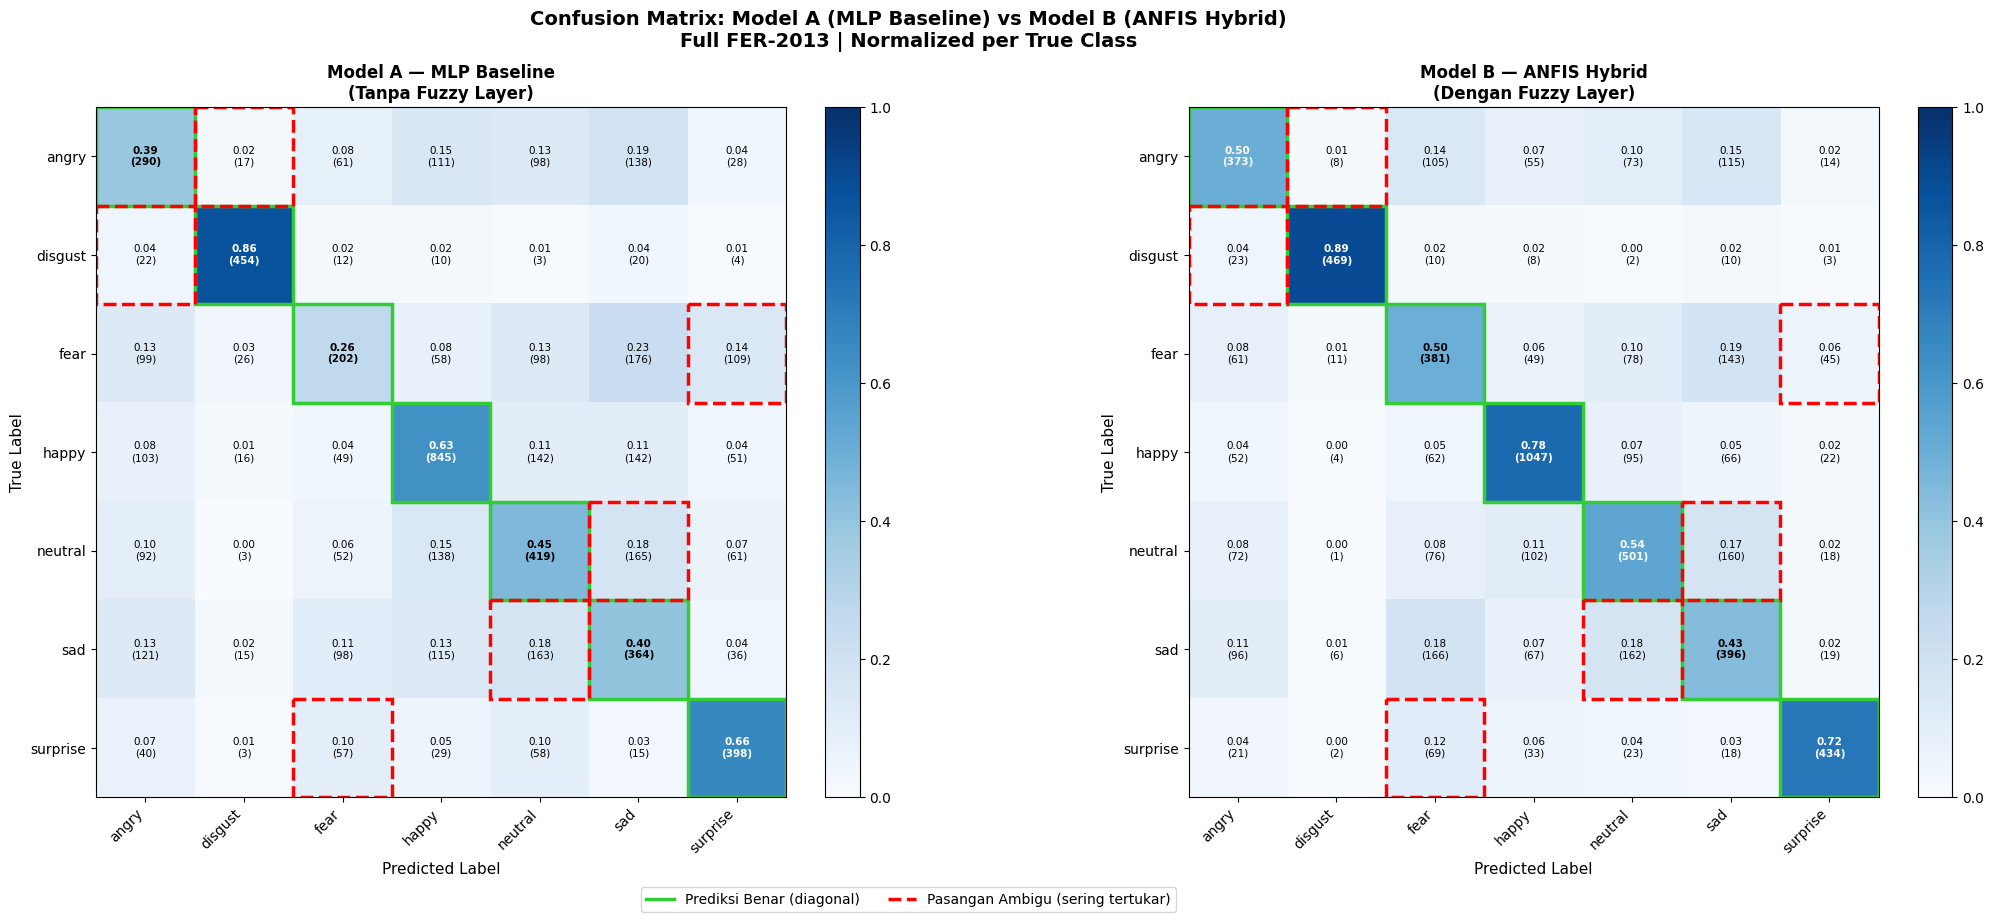

Confusion matrix komparatif tersimpan.

  ANALISIS KELAS AMBIGU — CONFUSION RATE COMPARISON

  Pair: SAD <-> NEUTRAL
  Alasan Ambigu   : Low-arousal, ekspresi minim gerakan
  Model A (MLP)   : sad→neutral: 17.9%  |  neutral→sad: 17.7%  |  avg=17.8%
  Model B (ANFIS) : sad→neutral: 17.8%  |  neutral→sad: 17.2%  |  avg=17.5%
  Reduksi Error   : +0.3%  →  ✓ ANFIS Lebih Baik

  Pair: ANGRY <-> DISGUST
  Alasan Ambigu   : Negative high-arousal, AU4+AU17 overlap
  Model A (MLP)   : angry→disgust: 2.3%  |  disgust→angry: 4.2%  |  avg=3.2%
  Model B (ANFIS) : angry→disgust: 1.1%  |  disgust→angry: 4.4%  |  avg=2.7%
  Reduksi Error   : +0.5%  →  ✓ ANFIS Lebih Baik

  Pair: FEAR <-> SURPRISE
  Alasan Ambigu   : Wide-eye + brow-raise (AU1+AU2+AU5)
  Model A (MLP)   : fear→surprise: 14.2%  |  surprise→fear: 9.5%  |  avg=11.8%
  Model B (ANFIS) : fear→surprise: 5.9%  |  surprise→fear: 11.5%  |  avg=8.7%
  Reduksi Error   : +3.2%  →  ✓ ANFIS Lebih Baik



In [ ]:
# ============================================================
# CELL 13: CONFUSION MATRIX KOMPARATIF + ANALISIS AMBIGUITAS
# ============================================================

AMBIGUOUS_PAIRS = [
    ('sad',   'neutral', 'Low-arousal, ekspresi minim gerakan'),
    ('angry', 'disgust', 'Negative high-arousal, AU4+AU17 overlap'),
    ('fear',  'surprise','Wide-eye + brow-raise (AU1+AU2+AU5)'),
]


def plot_confusion_matrices_comparative(y_true, y_pred_a, y_pred_b, cfg, save_dir):
    cm_a      = confusion_matrix(y_true, y_pred_a)
    cm_b      = confusion_matrix(y_true, y_pred_b)
    cm_a_norm = cm_a.astype(float) / cm_a.sum(axis=1, keepdims=True)
    cm_b_norm = cm_b.astype(float) / cm_b.sum(axis=1, keepdims=True)

    fig, axes = plt.subplots(1, 2, figsize=(22, 9))
    fig.suptitle(
        'Confusion Matrix: Model A (MLP Baseline) vs Model B (ANFIS Hybrid)\n'
        'Full FER-2013 | Normalized per True Class',
        fontsize=14, fontweight='bold')

    for ax, cm_norm, cm_raw, title in [
        (axes[0], cm_a_norm, cm_a, 'Model A — MLP Baseline\n(Tanpa Fuzzy Layer)'),
        (axes[1], cm_b_norm, cm_b, 'Model B — ANFIS Hybrid\n(Dengan Fuzzy Layer)'),
    ]:
        im = ax.imshow(cm_norm, interpolation='nearest', cmap='Blues', vmin=0, vmax=1)
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        ax.set_xticks(range(cfg.NUM_CLASSES))
        ax.set_yticks(range(cfg.NUM_CLASSES))
        ax.set_xticklabels(cfg.EMOTION_LABELS, rotation=45, ha='right', fontsize=10)
        ax.set_yticklabels(cfg.EMOTION_LABELS, fontsize=10)
        ax.set_title(title, fontweight='bold', fontsize=12)
        ax.set_xlabel('Predicted Label', fontsize=11)
        ax.set_ylabel('True Label', fontsize=11)

        for i in range(cfg.NUM_CLASSES):
            for j in range(cfg.NUM_CLASSES):
                v_norm = cm_norm[i, j]
                v_raw  = cm_raw[i, j]
                color  = 'white' if v_norm > 0.5 else 'black'
                ax.text(j, i, f'{v_norm:.2f}\n({v_raw})',
                        ha='center', va='center', color=color,
                        fontsize=7.5,
                        fontweight='bold' if i == j else 'normal')

        # Highlight diagonal (prediksi benar) — hijau
        for i in range(cfg.NUM_CLASSES):
            ax.add_patch(plt.Rectangle(
                (i - 0.5, i - 0.5), 1, 1,
                fill=False, edgecolor='limegreen', linewidth=2.5))

        # Highlight pasangan ambigu — merah putus-putus
        for em1, em2, _ in AMBIGUOUS_PAIRS:
            if em1 not in cfg.EMOTION_LABELS or em2 not in cfg.EMOTION_LABELS:
                continue
            i1 = cfg.EMOTION_LABELS.index(em1)
            i2 = cfg.EMOTION_LABELS.index(em2)
            for (ri, ci) in [(i1, i2), (i2, i1)]:
                ax.add_patch(plt.Rectangle(
                    (ci - 0.5, ri - 0.5), 1, 1,
                    fill=False, edgecolor='red', linewidth=2.5, linestyle='--'))

    from matplotlib.lines import Line2D
    legend_elements = [
        Line2D([0], [0], color='limegreen', lw=2.5,
               label='Prediksi Benar (diagonal)'),
        Line2D([0], [0], color='red', lw=2.5, ls='--',
               label='Pasangan Ambigu (sering tertukar)'),
    ]
    fig.legend(handles=legend_elements, loc='lower center',
               ncol=2, fontsize=10, bbox_to_anchor=(0.5, -0.03))

    plt.tight_layout()
    plt.savefig(f'{save_dir}/confusion_matrix_comparative.png',
                dpi=150, bbox_inches='tight')
    plt.show()
    print('Confusion matrix komparatif tersimpan.')
    return cm_a, cm_b, cm_a_norm, cm_b_norm


cm_a, cm_b, cm_a_norm, cm_b_norm = plot_confusion_matrices_comparative(
    y_true, y_pred_a, y_pred_b, cfg, cfg.RESULTS_DIR)

# ============================================================
# ANALISIS KUANTITATIF KELAS AMBIGU
# ============================================================
print('\n' + '=' * 68)
print('  ANALISIS KELAS AMBIGU — CONFUSION RATE COMPARISON')
print('=' * 68)

for em1, em2, reason in AMBIGUOUS_PAIRS:
    if em1 not in cfg.EMOTION_LABELS or em2 not in cfg.EMOTION_LABELS:
        continue
    i1 = cfg.EMOTION_LABELS.index(em1)
    i2 = cfg.EMOTION_LABELS.index(em2)

    conf_a_12 = cm_a_norm[i1, i2] * 100
    conf_a_21 = cm_a_norm[i2, i1] * 100
    conf_b_12 = cm_b_norm[i1, i2] * 100
    conf_b_21 = cm_b_norm[i2, i1] * 100

    avg_a  = (conf_a_12 + conf_a_21) / 2
    avg_b  = (conf_b_12 + conf_b_21) / 2
    delta  = avg_a - avg_b
    symbol = '✓ ANFIS Lebih Baik' if delta > 0 else '✗ MLP Lebih Baik'

    print(f'\n  Pair: {em1.upper()} <-> {em2.upper()}')
    print(f'  Alasan Ambigu   : {reason}')
    print(f'  Model A (MLP)   : {em1}→{em2}: {conf_a_12:.1f}%  |  '
          f'{em2}→{em1}: {conf_a_21:.1f}%  |  avg={avg_a:.1f}%')
    print(f'  Model B (ANFIS) : {em1}→{em2}: {conf_b_12:.1f}%  |  '
          f'{em2}→{em1}: {conf_b_21:.1f}%  |  avg={avg_b:.1f}%')
    print(f'  Reduksi Error   : {delta:+.1f}%  →  {symbol}')

print('\n' + '=' * 68)

## Cell 14: Analisis Keunggulan Fuzzy Layer

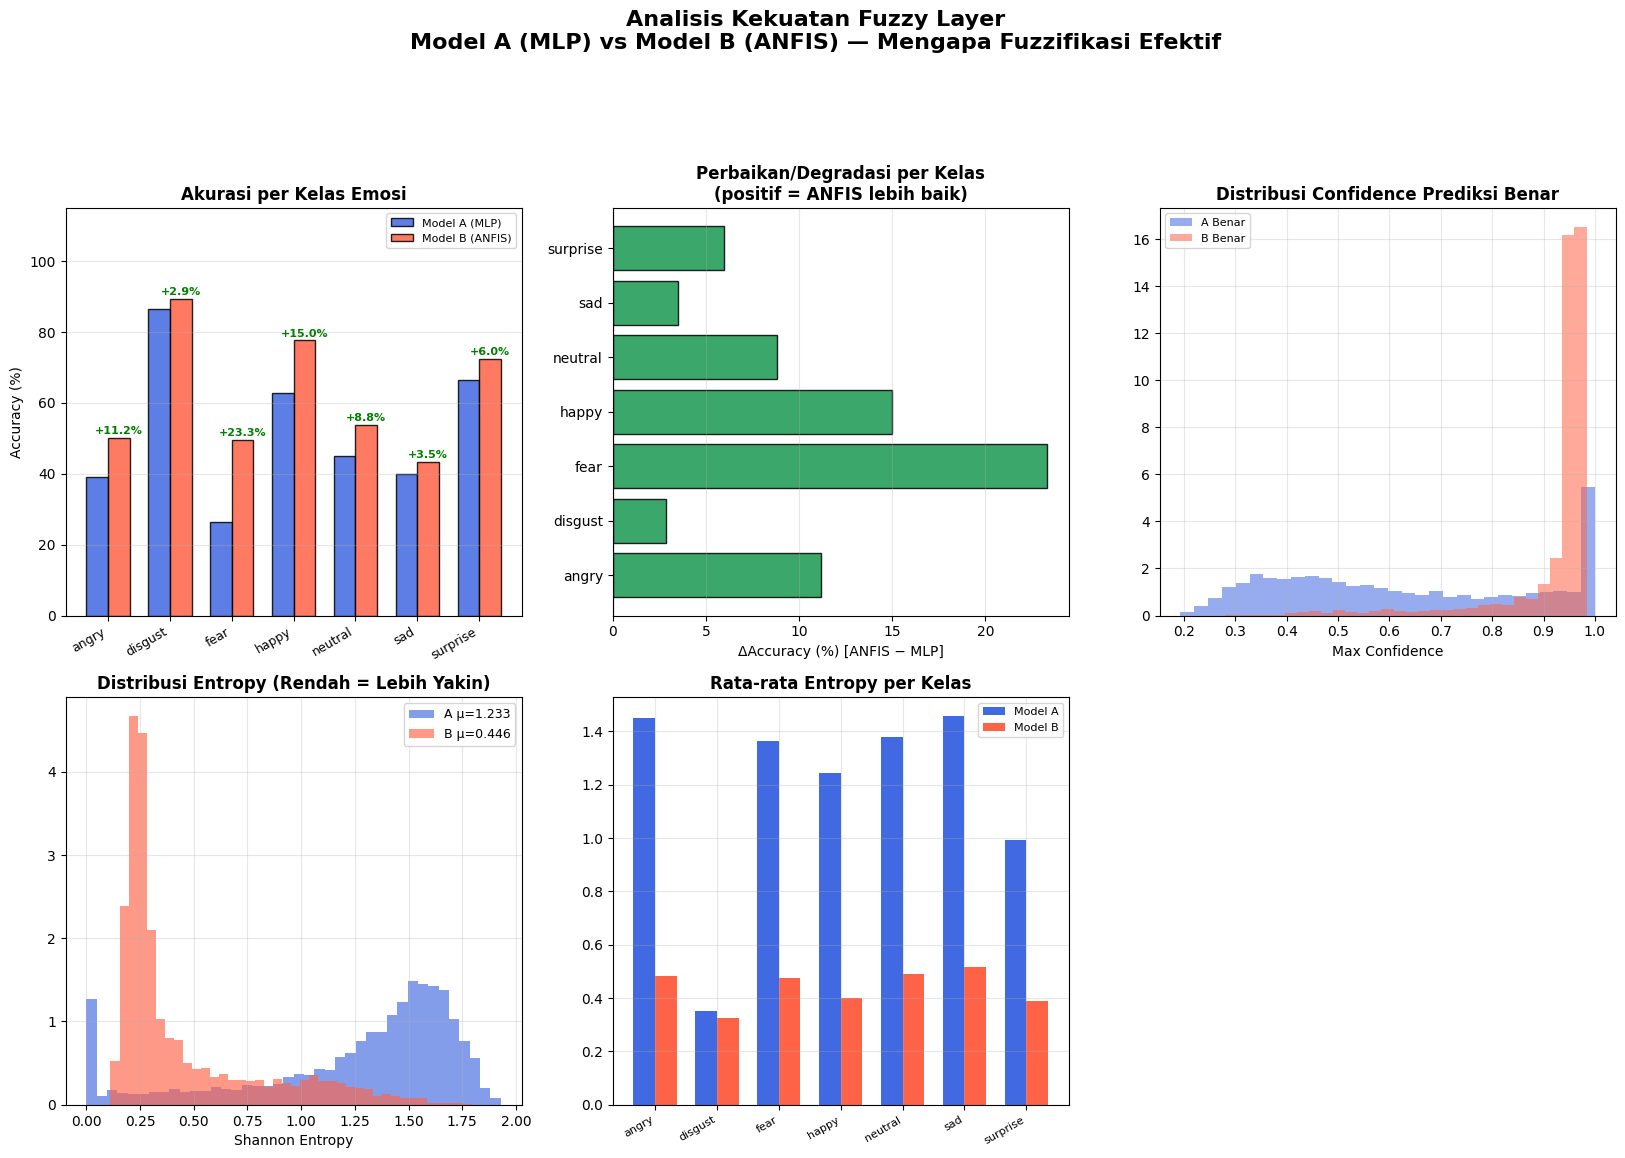

In [ ]:
# ============================================================
# CELL 14: ANALISIS KEUNGGULAN FUZZY LAYER
# ============================================================

def plot_fuzzy_advantage_analysis(probs_a, probs_b, y_true,
                                    cm_a_norm, cm_b_norm, cfg, save_dir):

    fig = plt.figure(figsize=(20, 18))
    fig.suptitle(
        'Analisis Kekuatan Fuzzy Layer\n'
        'Model A (MLP) vs Model B (ANFIS) — Mengapa Fuzzifikasi Efektif',
        fontsize=16, fontweight='bold', y=0.99)

    per_cls_a = cm_a_norm.diagonal() * 100
    per_cls_b = cm_b_norm.diagonal() * 100
    delta_cls = per_cls_b - per_cls_a
    w = 0.35
    x = np.arange(cfg.NUM_CLASSES)

    # ---- 1. Akurasi per kelas ----
    ax1 = fig.add_subplot(3, 3, 1)
    bars_a = ax1.bar(x - w/2, per_cls_a, w, color='royalblue', alpha=0.85,
                     label='Model A (MLP)', edgecolor='black')
    bars_b = ax1.bar(x + w/2, per_cls_b, w, color='tomato', alpha=0.85,
                     label='Model B (ANFIS)', edgecolor='black')
    ax1.set_xticks(x)
    ax1.set_xticklabels(cfg.EMOTION_LABELS, rotation=30, ha='right', fontsize=9)
    ax1.set_ylabel('Accuracy (%)')
    ax1.set_title('Akurasi per Kelas Emosi', fontweight='bold')
    ax1.legend(fontsize=8); ax1.grid(True, alpha=0.3, axis='y')
    ax1.set_ylim(0, 115)
    for ba, bb, d in zip(bars_a, bars_b, delta_cls):
        color = 'green' if d >= 0 else 'red'
        ax1.text(bb.get_x() + bb.get_width()/2., bb.get_height() + 0.5,
                 f'{d:+.1f}%', ha='center', va='bottom',
                 fontsize=8, color=color, fontweight='bold')

    # ---- 2. Delta per kelas (horizontal) ----
    ax2 = fig.add_subplot(3, 3, 2)
    delta_colors = ['#1a9850' if d >= 0 else '#d73027' for d in delta_cls]
    bars = ax2.barh(cfg.EMOTION_LABELS, delta_cls,
                    color=delta_colors, edgecolor='black', alpha=0.85)
    ax2.axvline(0, color='black', lw=1.5)
    ax2.set_xlabel('ΔAccuracy (%) [ANFIS − MLP]')
    ax2.set_title('Perbaikan/Degradasi per Kelas\n(positif = ANFIS lebih baik)',
                  fontweight='bold')
    ax2.grid(True, alpha=0.3, axis='x')

    # ---- 3. Distribusi max-confidence ----
    ax3 = fig.add_subplot(3, 3, 3)
    max_conf_a = probs_a.max(axis=1)
    max_conf_b = probs_b.max(axis=1)
    correct_a  = y_true == np.argmax(probs_a, axis=1)
    correct_b  = y_true == np.argmax(probs_b, axis=1)
    ax3.hist(max_conf_a[correct_a],  bins=30, alpha=0.55, color='royalblue', label='A Benar', density=True)
    ax3.hist(max_conf_b[correct_b],  bins=30, alpha=0.55, color='tomato', label='B Benar', density=True)
    ax3.set_xlabel('Max Confidence')
    ax3.set_title('Distribusi Confidence Prediksi Benar', fontweight='bold')
    ax3.legend(fontsize=8); ax3.grid(True, alpha=0.3)

    # ---- 4. Distribusi Entropy ----
    ax4 = fig.add_subplot(3, 3, 4)
    ent_a = np.array([scipy_entropy(p + 1e-10) for p in probs_a])
    ent_b = np.array([scipy_entropy(p + 1e-10) for p in probs_b])
    ax4.hist(ent_a, bins=40, alpha=0.65, color='royalblue', density=True, label=f'A μ={ent_a.mean():.3f}')
    ax4.hist(ent_b, bins=40, alpha=0.65, color='tomato', density=True, label=f'B μ={ent_b.mean():.3f}')
    ax4.set_xlabel('Shannon Entropy')
    ax4.set_title('Distribusi Entropy (Rendah = Lebih Yakin)', fontweight='bold')
    ax4.legend(fontsize=9); ax4.grid(True, alpha=0.3)

    # ---- 5. Entropy per kelas ----
    ax5 = fig.add_subplot(3, 3, 5)
    ent_cls_a, ent_cls_b = [], []
    for cls_idx in range(cfg.NUM_CLASSES):
        mask = y_true == cls_idx
        ent_cls_a.append(ent_a[mask].mean() if mask.sum() > 0 else 0)
        ent_cls_b.append(ent_b[mask].mean() if mask.sum() > 0 else 0)
    ax5.bar(x - w/2, ent_cls_a, w, color='royalblue', label='Model A')
    ax5.bar(x + w/2, ent_cls_b, w, color='tomato', label='Model B')
    ax5.set_xticks(x)
    ax5.set_xticklabels(cfg.EMOTION_LABELS, rotation=30, ha='right', fontsize=8)
    ax5.set_title('Rata-rata Entropy per Kelas', fontweight='bold')
    ax5.legend(fontsize=8); ax5.grid(True, alpha=0.3)

# Jalankan fungsi
plot_fuzzy_advantage_analysis(
    probs_a, probs_b, y_true,
    cm_a_norm, cm_b_norm, cfg, cfg.RESULTS_DIR)

## Cell 15: Analisis Matematika Kerutan -- Visualisasi LBP dan HOG

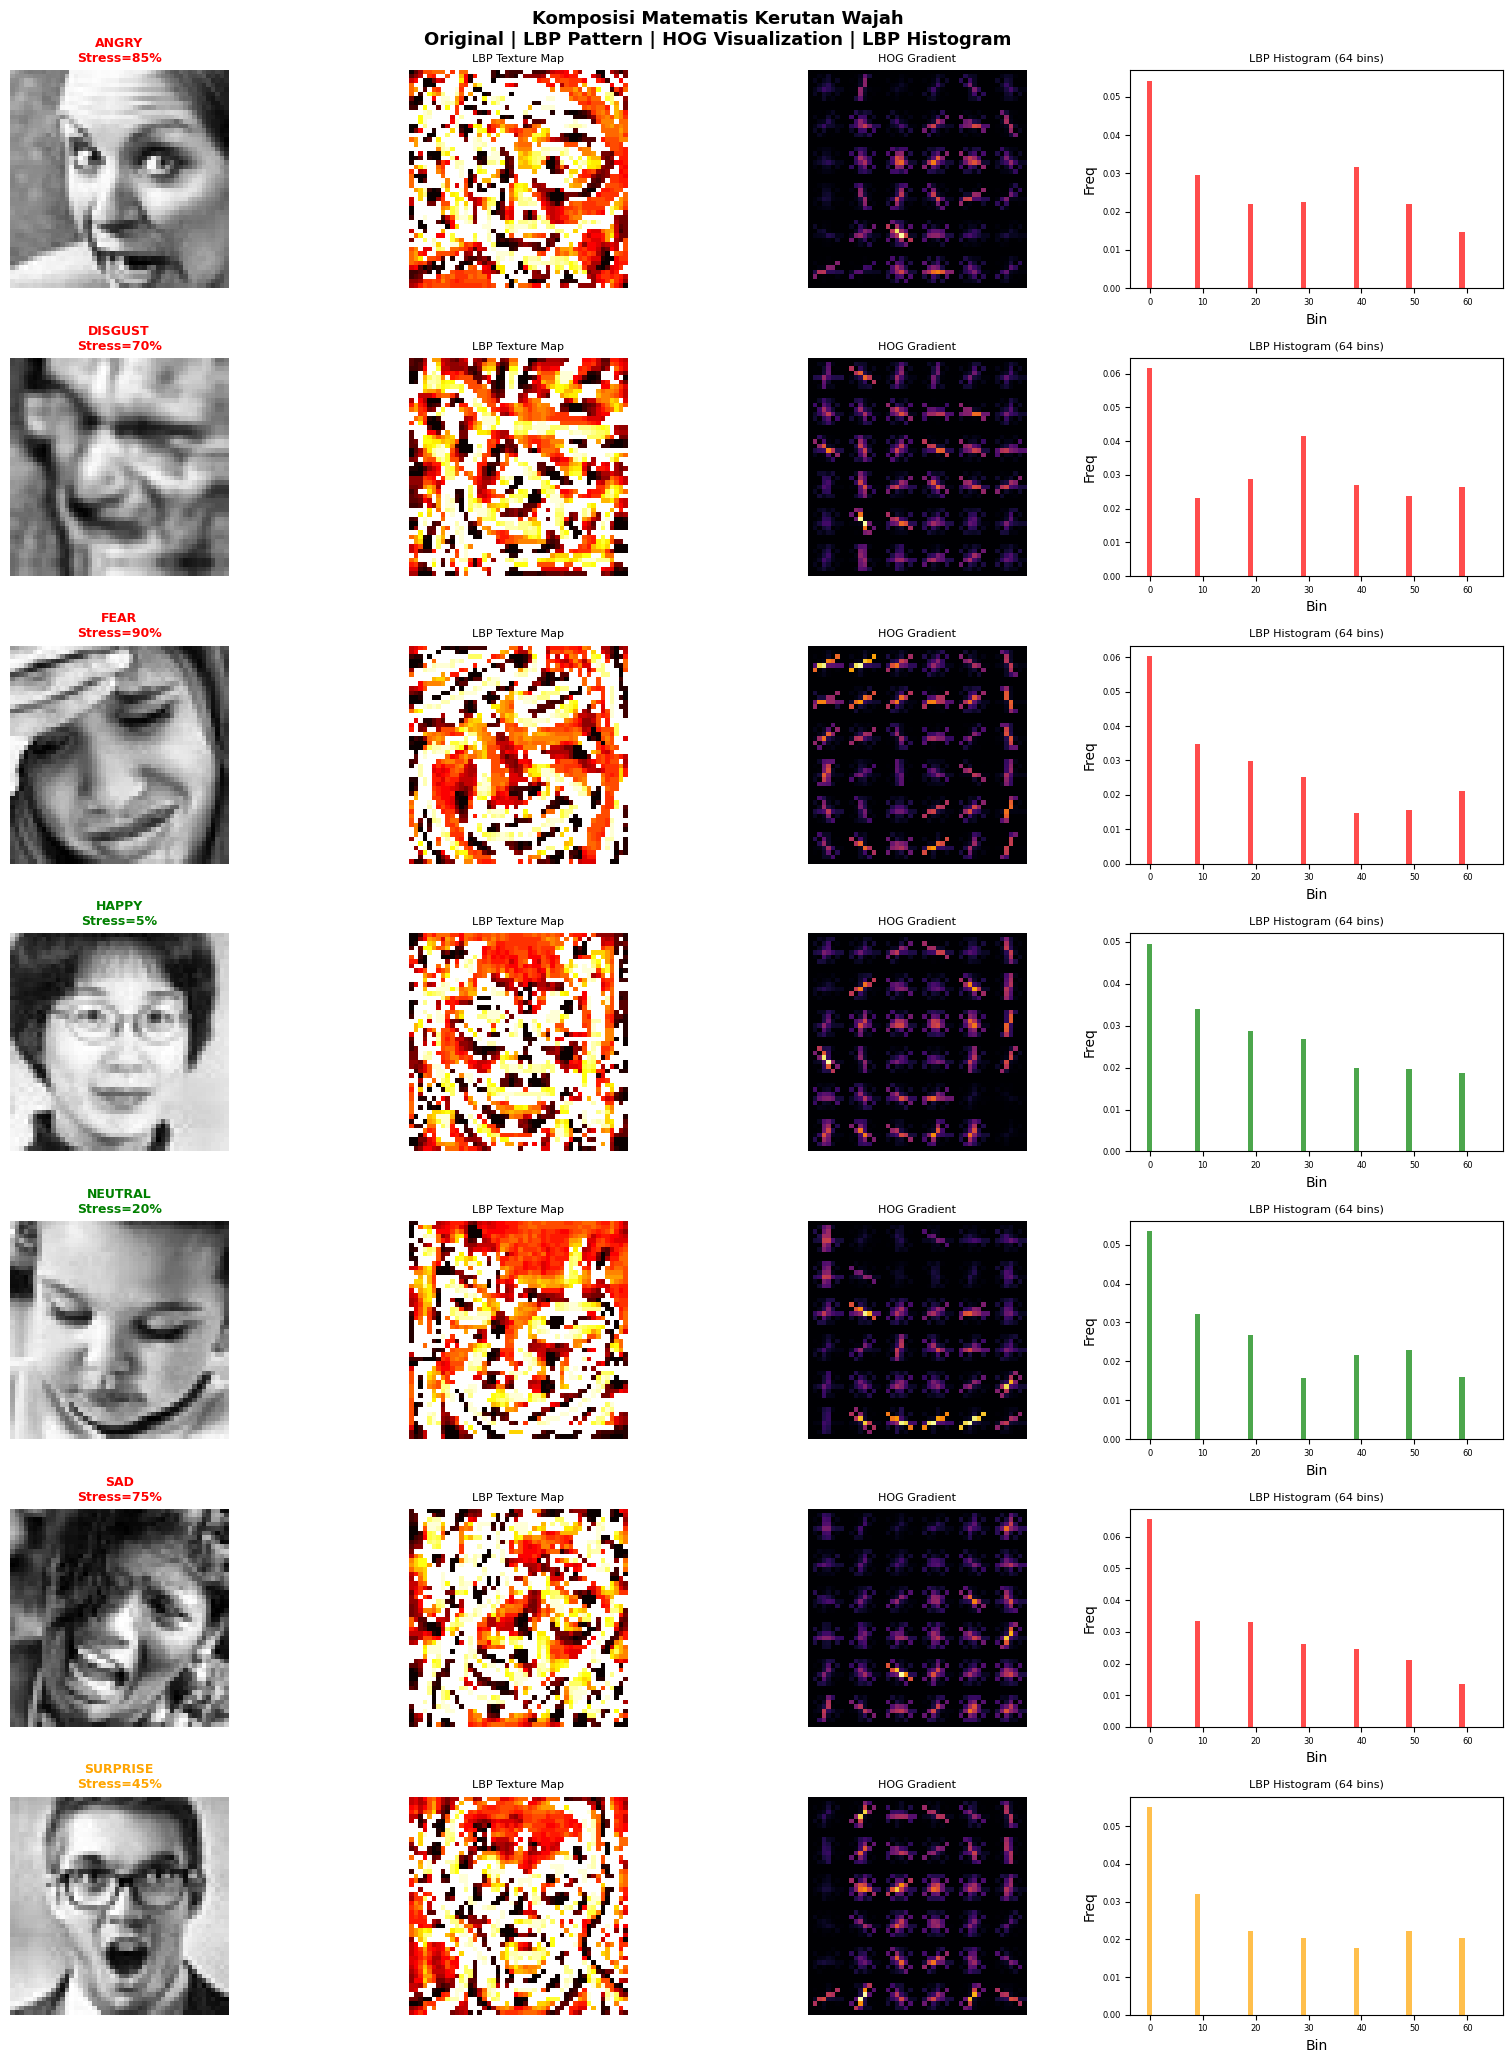

Visualisasi matematika kerutan tersimpan


In [ ]:
# ============================================================
# CELL 15: VISUALISASI KOMPOSISI MATEMATIKA KERUTAN WAJAH
# ============================================================

def visualize_wrinkle_math(X_data, y_data, cfg, n_samples=1):
    """
    Visualisasi LBP dan HOG pada contoh gambar wajah
    untuk menunjukkan komposisi matematis kerutan.
    Kolom: Original | LBP Pattern | HOG Visualization | LBP Histogram
    """
    n_rows = cfg.NUM_CLASSES * n_samples
    fig, axes = plt.subplots(n_rows, 4, figsize=(16, n_rows * 3))
    if n_rows == 1:
        axes = axes[np.newaxis, :]
    fig.suptitle(
        'Komposisi Matematis Kerutan Wajah\n'
        'Original | LBP Pattern | HOG Visualization | LBP Histogram',
        fontsize=13, fontweight='bold'
    )

    row = 0
    for label_idx, label in enumerate(cfg.EMOTION_LABELS):
        mask    = y_data == label_idx
        indices = np.where(mask)[0]
        n_avail = min(n_samples, len(indices))

        for j in range(n_avail):
            idx   = indices[j]
            img2d = X_data[idx]
            if img2d.ndim == 3:
                img2d = img2d[..., 0]

            img_uint8 = (img2d * 255).astype(np.uint8)

            lbp_img  = local_binary_pattern(img_uint8, 24, 3, method='uniform')
            lbp_hist, _ = np.histogram(lbp_img.ravel(), bins=256, range=(0, 26))
            lbp_hist_norm = lbp_hist / (lbp_hist.sum() + 1e-7)

            _, hog_img = hog(
                img_uint8,
                orientations=9,
                pixels_per_cell=(8, 8),
                cells_per_block=(2, 2),
                visualize=True,
                feature_vector=True
            )

            sw           = cfg.STRESS_WEIGHTS[label]
            stress_color = 'red' if sw > 0.66 else 'orange' if sw > 0.33 else 'green'

            axes[row, 0].imshow(img2d, cmap='gray')
            axes[row, 0].set_title(
                f'{label.upper()}\nStress={sw*100:.0f}%',
                fontsize=9, color=stress_color, fontweight='bold'
            )
            axes[row, 0].axis('off')

            axes[row, 1].imshow(lbp_img, cmap='hot')
            axes[row, 1].set_title('LBP Texture Map', fontsize=8)
            axes[row, 1].axis('off')

            axes[row, 2].imshow(hog_img, cmap='inferno')
            axes[row, 2].set_title('HOG Gradient', fontsize=8)
            axes[row, 2].axis('off')

            axes[row, 3].bar(range(min(64, len(lbp_hist_norm))),
                             lbp_hist_norm[:64],
                             color=stress_color, alpha=0.7, width=1.0)
            axes[row, 3].set_title('LBP Histogram (64 bins)', fontsize=8)
            axes[row, 3].set_xlabel('Bin')
            axes[row, 3].set_ylabel('Freq')
            axes[row, 3].tick_params(labelsize=6)
            row += 1

        for k in range(n_avail, n_samples):
            for c in range(4):
                axes[row, c].axis('off')
            row += 1

    plt.tight_layout()
    plt.savefig(f'{cfg.RESULTS_DIR}/wrinkle_math_analysis.png',
                dpi=120, bbox_inches='tight')
    plt.show()
    print('Visualisasi matematika kerutan tersimpan')


visualize_wrinkle_math(X_test, y_test, cfg, n_samples=1)

## Cell 16: Fungsi Inferensi dan Stress Level Dashboard

Demo Inferensi pada Sampel Test Set:

[Sample idx=6]
  True Emotion : angry
  Pred Emotion : angry (91.1%)
  Stress Level : 81.4 -> HIGH


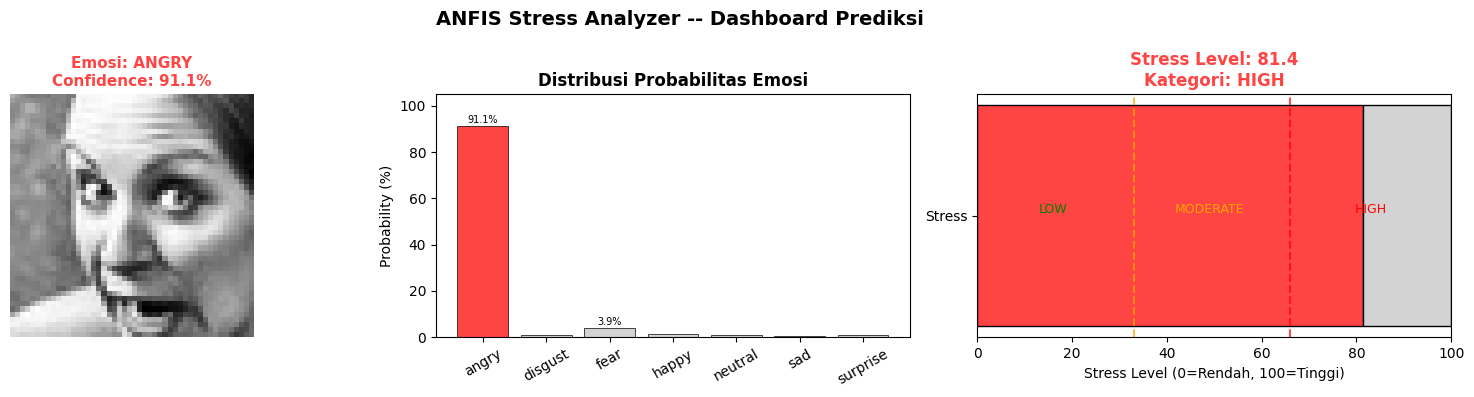


[Sample idx=8]
  True Emotion : disgust
  Pred Emotion : disgust (95.6%)
  Stress Level : 67.2 -> HIGH


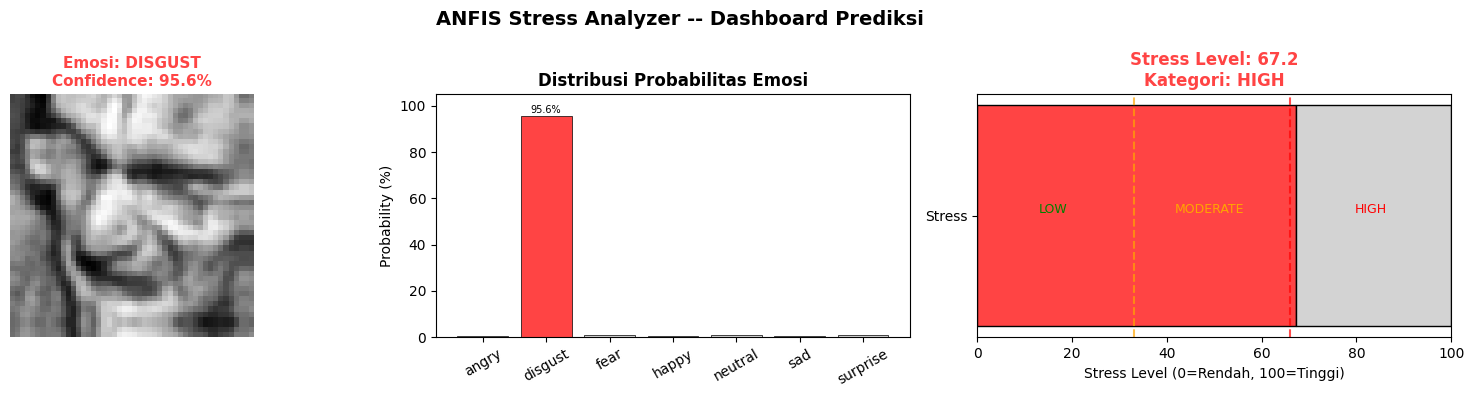


[Sample idx=5]
  True Emotion : fear
  Pred Emotion : sad (93.5%)
  Stress Level : 77.7 -> HIGH


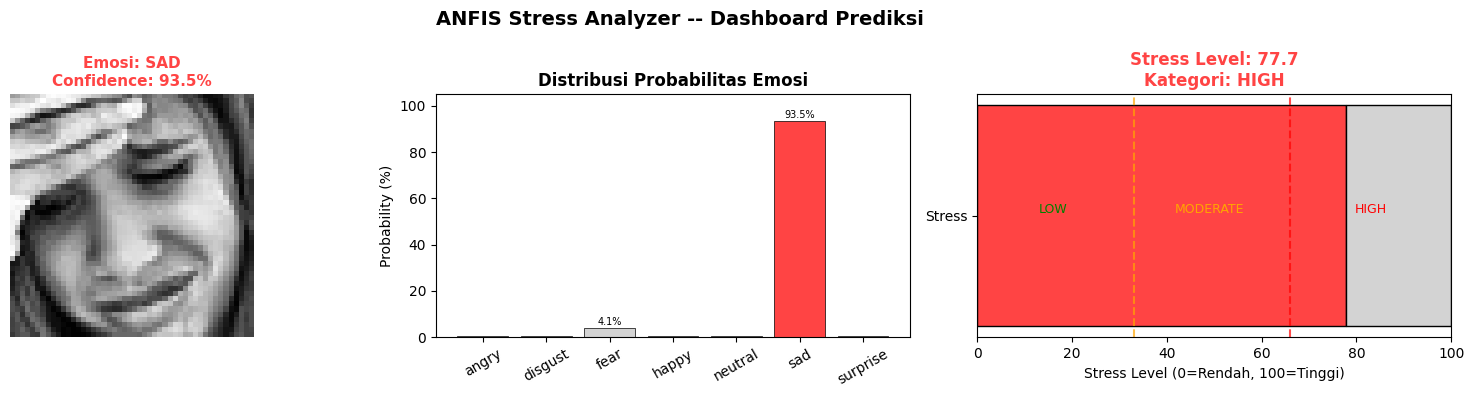


Dashboard prediksi tersimpan


In [ ]:
# ============================================================
# CELL 16: INFERENSI DAN STRESS LEVEL DASHBOARD
# ============================================================

def stress_category(level):
    """Kategorisasi stress level."""
    if level < 33:
        return 'LOW', '#22AA22'
    elif level < 66:
        return 'MODERATE', '#FFA500'
    else:
        return 'HIGH', '#FF4444'

def predict_single(image_input, model, cfg):
    """
    Inferensi single image.
    image_input: numpy array (H, W) grayscale, float32 0-1
    """
    img = cv2.resize(image_input, (cfg.IMG_SIZE, cfg.IMG_SIZE))
    img = img.astype(np.float32)
    if img.max() > 1.0:
        img /= 255.0

    img_cnn = img[np.newaxis, ..., np.newaxis]   # (1, 48, 48, 1)
    lbp_f   = extract_lbp_features(img, n_bins=cfg.LBP_FEATURES)[np.newaxis]
    hog_f   = extract_hog_features(img, target_size=cfg.HOG_FEATURES)[np.newaxis]

    emotion_p, stress_p = model(
        [img_cnn, lbp_f, hog_f], training=False
    )
    emotion_probs = emotion_p.numpy()[0]
    stress_level  = float(stress_p.numpy()[0, 0]) * 100

    top_idx    = int(np.argmax(emotion_probs))
    top_label  = cfg.EMOTION_LABELS[top_idx]
    confidence = float(emotion_probs[top_idx])
    cat, color = stress_category(stress_level)

    return {
        'emotion':      top_label,
        'confidence':   confidence,
        'all_probs':    {cfg.EMOTION_LABELS[i]: float(emotion_probs[i])
                         for i in range(cfg.NUM_CLASSES)},
        'stress_level': stress_level,
        'stress_cat':   cat,
        'stress_color': color
    }

def show_prediction_dashboard(result, img_2d=None):
    """Tampilkan dashboard prediksi satu gambar."""
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    fig.suptitle('ANFIS Stress Analyzer -- Dashboard Prediksi',
                 fontsize=14, fontweight='bold')

    if img_2d is not None:
        axes[0].imshow(img_2d, cmap='gray')
    else:
        axes[0].text(0.5, 0.5, 'No Image', ha='center', va='center',
                     transform=axes[0].transAxes, fontsize=14)
    axes[0].set_title(
        f"Emosi: {result['emotion'].upper()}\n"
        f"Confidence: {result['confidence']*100:.1f}%",
        fontsize=11, fontweight='bold', color=result['stress_color']
    )
    axes[0].axis('off')

    probs       = result['all_probs']
    labels      = list(probs.keys())
    values      = list(probs.values())
    bar_colors  = [result['stress_color'] if l == result['emotion']
                   else 'lightgray' for l in labels]
    bars = axes[1].bar(labels, [v * 100 for v in values],
                       color=bar_colors, edgecolor='black', linewidth=0.5)
    axes[1].set_title('Distribusi Probabilitas Emosi', fontweight='bold')
    axes[1].set_ylabel('Probability (%)')
    axes[1].set_ylim(0, 105)
    axes[1].tick_params(axis='x', rotation=30)
    for bar, v in zip(bars, values):
        if v > 0.02:
            axes[1].text(bar.get_x() + bar.get_width() / 2.,
                         bar.get_height() + 0.5,
                         f'{v*100:.1f}%', ha='center', va='bottom', fontsize=7)

    sl = result['stress_level']
    axes[2].barh(['Stress'], [sl], color=result['stress_color'],
                 height=0.4, edgecolor='black')
    axes[2].barh(['Stress'], [100 - sl], left=sl, color='lightgray',
                 height=0.4, edgecolor='black')
    axes[2].axvline(33, color='orange', linestyle='--', alpha=0.7)
    axes[2].axvline(66, color='red',    linestyle='--', alpha=0.7)
    axes[2].set_xlim(0, 100)
    axes[2].set_title(
        f"Stress Level: {sl:.1f}\nKategori: {result['stress_cat']}",
        fontsize=12, fontweight='bold', color=result['stress_color']
    )
    axes[2].set_xlabel('Stress Level (0=Rendah, 100=Tinggi)')
    axes[2].text(16, 0, 'LOW',      ha='center', va='bottom', fontsize=9, color='green')
    axes[2].text(49, 0, 'MODERATE', ha='center', va='bottom', fontsize=9, color='orange')
    axes[2].text(83, 0, 'HIGH',     ha='center', va='bottom', fontsize=9, color='red')

    plt.tight_layout()
    plt.savefig(f'{cfg.RESULTS_DIR}/prediction_dashboard.png', dpi=150)
    plt.show()

# Demo: 3 contoh dari test set
print('Demo Inferensi pada Sampel Test Set:')
print('=' * 60)

demo_indices = []
for label_idx in range(cfg.NUM_CLASSES):
    idxs = np.where(y_test == label_idx)[0]
    if len(idxs) > 0:
        demo_indices.append(idxs[0])

for idx in demo_indices[:3]:
    img2d  = X_test[idx]
    result = predict_single(img2d, model_b, cfg)
    true_label = cfg.EMOTION_LABELS[y_test[idx]]

    print(f'\n[Sample idx={idx}]')
    print(f'  True Emotion : {true_label}')
    print(f'  Pred Emotion : {result["emotion"]} ({result["confidence"]*100:.1f}%)')
    print(f'  Stress Level : {result["stress_level"]:.1f} -> {result["stress_cat"]}')

    show_prediction_dashboard(result, img2d)

print('\nDashboard prediksi tersimpan')

## Cell 17: Simpan Model dan Laporan Akhir

In [ ]:
# ============================================================
# CELL 17: SIMPAN MODEL DAN LAPORAN AKHIR
# ============================================================

from pathlib import Path
import json
import pandas as pd

# 1. Model B — ANFIS Hybrid
full_model_path  = '/content/anfis_hybrid_full_model'
keras_b_path     = '/content/anfis_hybrid_full_model.keras'
model_b.export(full_model_path)
model_b.save(keras_b_path)
print(f'[Model B] SavedModel : {full_model_path}')
print(f'[Model B] Keras      : {keras_b_path}')

# 2. Model A — MLP Baseline
keras_a_path = '/content/mlp_baseline_model.keras'
model_a.save(keras_a_path)
print(f'[Model A] Keras      : {keras_a_path}')

# 3. Konfigurasi + hasil
cfg_dict = {
    'IMG_SIZE':         cfg.IMG_SIZE,
    'NUM_CLASSES':      cfg.NUM_CLASSES,
    'EMOTION_LABELS':   cfg.EMOTION_LABELS,
    'STRESS_WEIGHTS':   cfg.STRESS_WEIGHTS,
    'ANFIS_RULES':      cfg.ANFIS_RULES,
    'ANFIS_DIM':        cfg.ANFIS_DIM,
    'USE_FULL_DATASET': cfg.USE_FULL_DATASET,
    'RESULTS': {
        'model_a': {
            'accuracy':    float(acc_a),
            'f1_weighted': float(f1_a),
            'f1_macro':    float(f1m_a)},
        'model_b': {
            'accuracy':    float(acc_b),
            'f1_weighted': float(f1_b),
            'f1_macro':    float(f1m_b),
            'stress_mae':  float(stress_mae),
            'stress_rmse': float(stress_rmse)},
    }
}
with open(f'{cfg.RESULTS_DIR}/experiment_config.json', 'w') as f:
    json.dump(cfg_dict, f, indent=2)

# 4. History CSV
pd.DataFrame(history_a.history).to_csv(
    f'{cfg.RESULTS_DIR}/history_model_a.csv', index=False)
pd.DataFrame(history_b.history).to_csv(
    f'{cfg.RESULTS_DIR}/history_model_b.csv', index=False)

print('\nOutput files:')
for fp in sorted(Path(cfg.RESULTS_DIR).iterdir()):
    print(f'  {fp.name:<52} ({fp.stat().st_size/1024:.1f} KB)')

## Cell 18: Visualisasi Fuzzy Membership Functions

In [ ]:
# ============================================================
# CELL 18: VISUALISASI FUZZY MEMBERSHIP FUNCTIONS
# ============================================================

def plot_learned_mf(model, n_dims_to_show=4, cfg=None):
    """Plot Gaussian MF yang dipelajari oleh FuzzificationLayer."""

    fuzz_layer = None
    for layer in model.layers:
        if isinstance(layer, FuzzificationLayer):
            fuzz_layer = layer
            break

    if fuzz_layer is None:
        print('FuzzificationLayer tidak ditemukan')
        return

    centers   = fuzz_layer.centers.numpy()                # (D, n_mf)
    sigmas    = np.abs(fuzz_layer.sigmas.numpy()) + 1e-7  # (D, n_mf)
    n_mf      = centers.shape[1]
    D         = centers.shape[0]
    dims      = min(n_dims_to_show, D)

    fig, axes = plt.subplots(1, dims, figsize=(dims * 4, 4))
    if dims == 1:
        axes = [axes]

    fig.suptitle(
        'Learned Gaussian Membership Functions (ANFIS)\n'
        'Fungsi Keanggotaan Fuzzy yang Dipelajari',
        fontsize=13, fontweight='bold'
    )

    x_range   = np.linspace(-3, 3, 300)
    mf_colors = ['steelblue', 'tomato', 'forestgreen', 'purple', 'orange']

    for d in range(dims):
        ax = axes[d]
        for m in range(n_mf):
            c  = centers[d, m]
            s  = sigmas[d, m]
            mu = np.exp(-0.5 * ((x_range - c) / s) ** 2)
            ax.plot(x_range, mu,
                    color=mf_colors[m % len(mf_colors)],
                    linewidth=2,
                    label=f'MF{m+1}: c={c:.2f}, s={s:.2f}')
            ax.axvline(c, color=mf_colors[m % len(mf_colors)],
                       linestyle=':', alpha=0.4)

        ax.set_title(f'Dimensi {d+1}', fontweight='bold')
        ax.set_xlabel('Input Value')
        ax.set_ylabel('mu(x) -- Derajat Keanggotaan')
        ax.set_ylim(-0.05, 1.1)
        ax.legend(fontsize=7)
        ax.grid(True, alpha=0.3)
        ax.fill_between(
            x_range,
            np.zeros_like(x_range),
            np.exp(-0.5 * ((x_range - centers[d, 0]) / sigmas[d, 0]) ** 2),
            alpha=0.1, color=mf_colors[0]
        )

    plt.tight_layout()
    plt.savefig(f'{cfg.RESULTS_DIR}/anfis_membership_functions.png',
                dpi=150, bbox_inches='tight')
    plt.show()

    c_range = centers.max() - centers.min()
    s_mean  = sigmas.mean()
    print('Membership Functions divisualisasikan')
    print(f'  Dimensi ANFIS : {D}')
    print(f'  MF per input  : {n_mf}')
    print(f'  Total rules   : {cfg.ANFIS_RULES}')
    print(f'  Center range  : [{centers.min():.3f}, {centers.max():.3f}] (spread={c_range:.3f})')
    print(f'  Sigma mean    : {s_mean:.3f}')


plot_learned_mf(model_b, n_dims_to_show=4, cfg=cfg)

---

## Ringkasan Eksperimen Perbandingan

### Desain Eksperimen

| Komponen | Detail |
|---|---|
| Dataset | FER-2013 **FULL**  |
| Split | Stratified 70% train / 15% val / 15% test |
| Feature Extraction | Identik: CNN (MobileNetV2) + LBP + HOG → 836-dim fused |
| Model A | Dense MLP (hard decision boundary, tanpa Fuzzy) |
| Model B | ANFIS Hybrid (5 fuzzy layers + dual output) |

### Formula ANFIS Core (Model B)

| Layer | Formula | Fungsi |
|---|---|---|
| L1: Fuzzifikasi | `μ(x) = exp(−0.5·((x−c)/σ)²)` | Input → Derajat keanggotaan Gaussian |
| L2: Rule Firing | `wₖ = ∏ μᵢⱼ(xᵢ)` | T-norm product antar MF |
| L3: Normalisasi | `w̄ₖ = wₖ / Σwⱼ` | Normalisasi bobot rule |
| L4: Consequent  | `fₖ = p₀ + Σpᵢxᵢ` | TSK linear consequent |
| L5: Output      | `y = Σ w̄ₖ·fₖ(x)` | Defuzzifikasi (weighted average) |

### Pemetaan Stress Level (Model B)

| Emosi | Stress Weight | Kategori |
|---|---|---|
| fear | 90% | HIGH |
| angry | 85% | HIGH |
| sad | 75% | HIGH |
| disgust | 70% | MODERATE-HIGH |
| surprise | 45% | MODERATE |
| neutral | 20% | LOW |
| happy | 5% | LOW |